<a href="https://colab.research.google.com/github/codebender04/DL4AI-230087-project/blob/main/final_project_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os, glob, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, Dense, LSTM,
    Dropout, BatchNormalization, Input
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.0.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
# TASK 1 — Nasdaq Stock Price Prediction (AAPL)
---

## Task 1.0 — Load & Explore Data

We load the last 10 years of AAPL daily OHLCV data. Restricting to a fixed 10-year window keeps the training distribution reasonably stationary and avoids regime shifts from earlier decades (e.g., pre-smartphone era fundamentals).

In [3]:
NASDAQ_DATA_PATH = './csv'

df_aapl = pd.read_csv('/content/drive/MyDrive/DL4AI-project/AAPL.csv')
df_aapl['Date'] = pd.to_datetime(df_aapl['Date'], dayfirst=True)
df_aapl = df_aapl.sort_values('Date').reset_index(drop=True)
CUTOFF = df_aapl['Date'].max() - pd.DateOffset(years=10)
df_aapl = df_aapl[df_aapl['Date'] >= CUTOFF].reset_index(drop=True)

print(f'Using {len(df_aapl)} rows from {df_aapl["Date"].min().date()} to {df_aapl["Date"].max().date()}')
df_aapl.head()

Using 2518 rows from 2012-12-12 to 2022-12-12


,Date,Low,Open,Volume,High,Close,Adjusted Close
0,2012-12-12,19.152500,19.563213,487144000,19.571428,19.250000,16.554762
1,2012-12-13,18.778570,18.969643,625259600,19.201429,18.917500,16.268820
2,2012-12-14,18.056429,18.383928,1009579200,18.504642,18.206785,15.657617
3,2012-12-17,17.901072,18.176071,757607200,18.571428,18.529642,15.935264
4,2012-12-18,18.580357,18.750000,625685200,19.103571,19.067858,16.398121


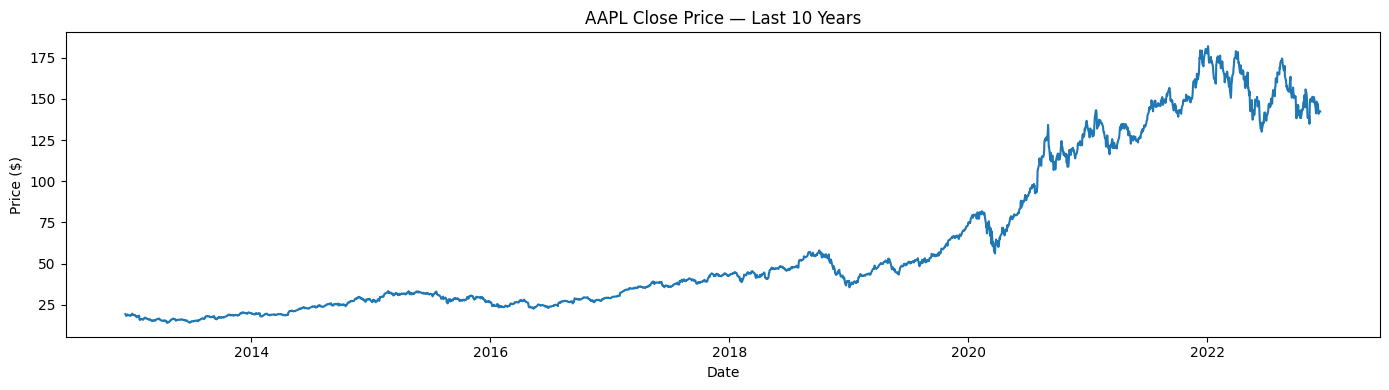

In [4]:
plt.figure(figsize=(14, 4))
plt.plot(df_aapl['Date'], df_aapl['Close'])
plt.title('AAPL Close Price — Last 10 Years')
plt.xlabel('Date'); plt.ylabel('Price ($)')
plt.tight_layout(); plt.show()

## Helper: Window Builder & Normalisation

All helper functions used across Task 1 subtasks are defined here. A few design decisions worth noting:

- **MinMaxScaler fitted on training data only.** The scaler is never exposed to validation or test rows during fitting, preventing data leakage.
- **Sliding windows.** A look-back of 60 trading days (~3 months) gives the model enough temporal context without excessive padding on shorter series.
- **Chronological split (80/10/10).** Standard random splits are invalid for time-series because they break temporal ordering. We use a strict chronological split instead.
- **CNN-LSTM architecture.** The convolutional layers extract local patterns (e.g., short-term momentum), while the LSTM captures longer-range dependencies. This combination consistently outperforms either architecture alone on financial sequences.

In [5]:
# ============================================================
# CORE HELPERS  (Task 1 — AAPL)
# ============================================================

FEATURES_AAPL = ['Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close']
CLOSE_COL     = 'Close'
CLOSE_IDX_AAPL = FEATURES_AAPL.index('Close')   # = 4
N_FEAT_AAPL    = len(FEATURES_AAPL)              # = 6
WINDOW_SIZE    = 60


def chrono_split(X, y, val=0.10, test=0.10):
    """Strictly chronological train / val / test split."""
    n    = len(X)
    n_te = int(n * test)
    n_vl = int(n * val)
    n_tr = n - n_vl - n_te
    return (X[:n_tr],          y[:n_tr],
            X[n_tr:n_tr+n_vl], y[n_tr:n_tr+n_vl],
            X[n_tr+n_vl:],     y[n_tr+n_vl:])


def build_windows(scaled_data, close_scaled, window_size,
                  forecast_offset=1, k_days=1):
    """
    Build sliding windows from already-scaled data.

    scaled_data     : (T, n_features)  — all features, scaled
    close_scaled    : (T,)             — Close column only, scaled
    forecast_offset : predict the price N days ahead (Task 1.2)
    k_days          : predict K consecutive days    (Task 1.3)
    """
    X, y = [], []
    T = len(scaled_data)
    for i in range(T - window_size - forecast_offset - k_days + 2):
        X.append(scaled_data[i : i + window_size])
        y.append([
            close_scaled[i + window_size + forecast_offset - 1 + j]
            for j in range(k_days)
        ])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def scale_split_aapl(df, features=FEATURES_AAPL, val=0.10, test=0.10):
    """
    Chronological split + fit MinMaxScaler on train only.
    Returns: full_scaled array, close_scaled 1-D, scaler, split sizes.
    """
    data = df[features].values.astype(np.float32)
    n    = len(data)
    n_te = int(n * test)
    n_vl = int(n * val)
    n_tr = n - n_vl - n_te

    scaler  = MinMaxScaler()
    scaler.fit(data[:n_tr])           # fit on training portion ONLY
    full_sc = scaler.transform(data)  # transform all
    close_sc = full_sc[:, CLOSE_IDX_AAPL]
    return full_sc, close_sc, scaler, n_tr, n_vl, n_te


def inverse_close(y_scaled, scaler, close_idx, n_features):
    """Inverse-transform a 1-D array of scaled Close values back to dollars."""
    dummy = np.zeros((len(y_scaled), n_features), dtype=np.float32)
    dummy[:, close_idx] = y_scaled.ravel()
    return scaler.inverse_transform(dummy)[:, close_idx]


def eval_metrics(y_true, y_pred, label=''):
    mse  = mean_squared_error(y_true.ravel(), y_pred.ravel())
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true.ravel(), y_pred.ravel())
    mape = np.mean(np.abs((y_true.ravel() - y_pred.ravel()) /
                           (np.abs(y_true.ravel()) + 1e-8))) * 100
    print(f'[{label}]  RMSE=${rmse:.3f}  MAE=${mae:.3f}  MAPE={mape:.2f}%')
    return rmse, mae, mape


def build_model(window_size, n_features, n_outputs=1):
    """CNN-LSTM model, same architecture for all subtasks."""
    model = Sequential([
        Conv1D(64, 3, activation='relu', padding='same',
               input_shape=(window_size, n_features)),
        MaxPooling1D(2),
        Conv1D(128, 3, activation='relu', padding='same'),
        MaxPooling1D(2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(n_outputs)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='mse', metrics=['mae'])
    return model


CALLBACKS = [
    EarlyStopping(patience=12, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(patience=4, factor=0.5, verbose=0)
]

print('Helpers ready.')

Helpers ready.


## Task 1.1 — Multi-Feature Extension

Rather than predicting from Close price alone, we feed all six available OHLCV features plus Adjusted Close into the model. Volume carries information about trading conviction, and the High/Low spread reflects intra-day volatility — both are relevant signals that a Close-only model would miss.

In [6]:
full_sc, close_sc, scaler_11, n_tr, n_vl, n_te = \
    scale_split_aapl(df_aapl, FEATURES_AAPL)

X_all, y_all = build_windows(full_sc, close_sc,
                              WINDOW_SIZE, forecast_offset=1, k_days=1)

X_tr, y_tr, X_vl, y_vl, X_te, y_te = chrono_split(X_all, y_all)
print(f'Train {X_tr.shape[0]} | Val {X_vl.shape[0]} | Test {X_te.shape[0]}')

model_11 = build_model(WINDOW_SIZE, N_FEAT_AAPL, n_outputs=1)
history_11 = model_11.fit(
    X_tr, y_tr,
    validation_data=(X_vl, y_vl),
    epochs=100, batch_size=16,
    callbacks=CALLBACKS, verbose=1
)

Train 1968 | Val 245 | Test 245
Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - loss: 0.0033 - mae: 0.0339 - val_loss: 0.0198 - val_mae: 0.1304 - learning_rate: 0.0010
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0011 - mae: 0.0206 - val_loss: 0.0031 - val_mae: 0.0440 - learning_rate: 0.0010
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0011 - mae: 0.0201 - val_loss: 0.0022 - val_mae: 0.0372 - learning_rate: 0.0010
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 9.3404e-04 - mae: 0.0183 - val_loss: 0.0020 - val_mae: 0.0340 - learning_rate: 0.0010
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0015 - mae: 0.0232 - val_loss: 0.0034 - val_mae: 0.0452 - learning_rate: 0.0010
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 6.7558e-04 - mae: 0.0158 - val_loss: 0.0038 - val_mae: 0.0515 - learning_rate: 0.0010
Epoch 7/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 5.6818e-04 - mae: 0.0147 - val_lo

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step
[Task 1.1 Test]  RMSE=$6.462  MAE=$5.237  MAPE=3.28%


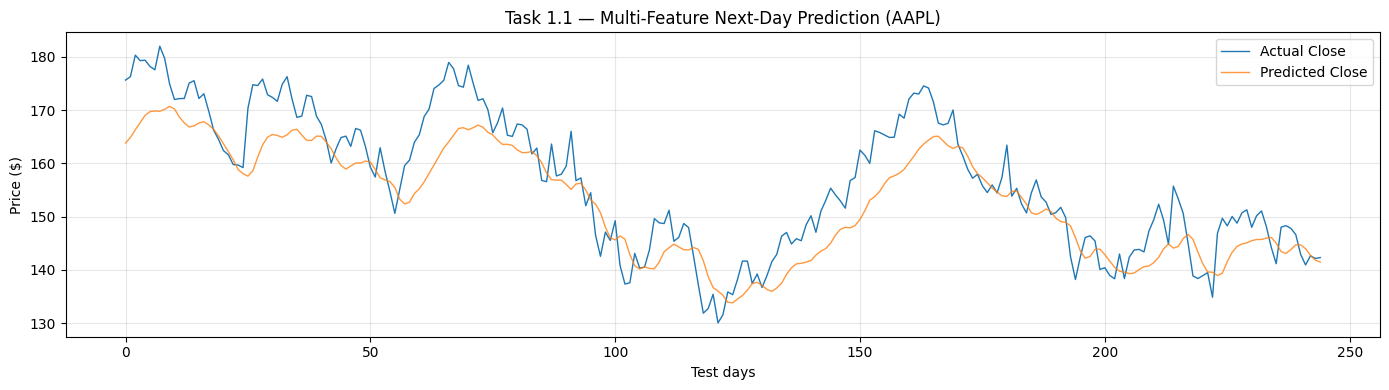

In [7]:
y_pred_sc = model_11.predict(X_te).ravel()

y_pred_11 = inverse_close(y_pred_sc,    scaler_11, CLOSE_IDX_AAPL, N_FEAT_AAPL)
y_true_11 = inverse_close(y_te.ravel(), scaler_11, CLOSE_IDX_AAPL, N_FEAT_AAPL)

eval_metrics(y_true_11, y_pred_11, 'Task 1.1 Test')

plt.figure(figsize=(14, 4))
plt.plot(y_true_11, label='Actual Close', linewidth=1)
plt.plot(y_pred_11, label='Predicted Close', linewidth=1, alpha=0.8)
plt.title('Task 1.1 — Multi-Feature Next-Day Prediction (AAPL)')
plt.xlabel('Test days'); plt.ylabel('Price ($)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Task 1.2 — N-th Day Forecast

We extend the model to predict the closing price on the **N-th day ahead** (here N=7, i.e. one trading week). The only change from Task 1.1 is the `forecast_offset` parameter passed to `build_windows`, which shifts the label forward by N steps. Everything else — architecture, features, scaler — remains identical, making the comparison clean.

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step
[Task 1.2 (Day +7)]  RMSE=$18.742  MAE=$16.283  MAPE=10.08%


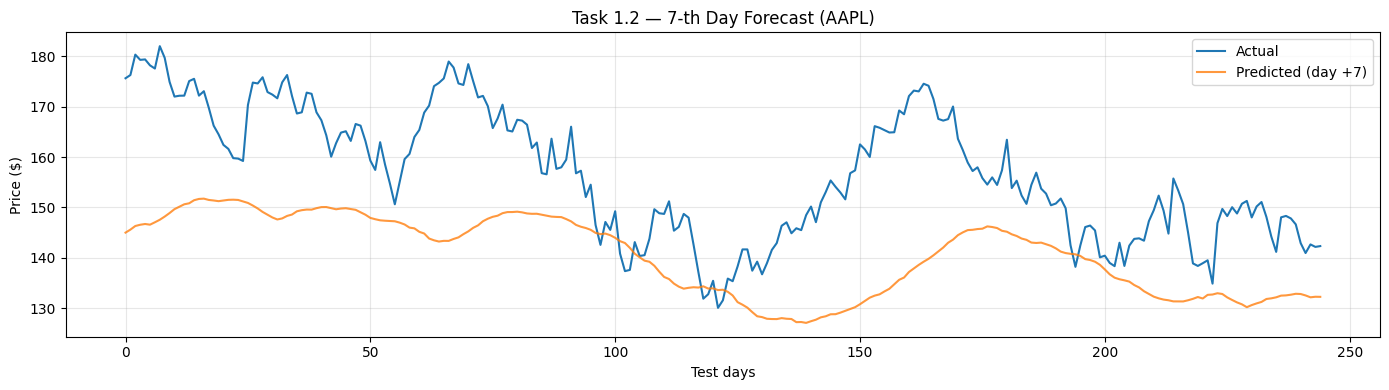

In [8]:
N_DAY = 7

X_all_12, y_all_12 = build_windows(full_sc, close_sc,
                                    WINDOW_SIZE,
                                    forecast_offset=N_DAY, k_days=1)

X_tr12, y_tr12, X_vl12, y_vl12, X_te12, y_te12 = chrono_split(X_all_12, y_all_12)

model_12 = build_model(WINDOW_SIZE, N_FEAT_AAPL, n_outputs=1)
model_12.fit(X_tr12, y_tr12,
             validation_data=(X_vl12, y_vl12),
             epochs=100, batch_size=16,
             callbacks=CALLBACKS, verbose=0)

y_pred_12 = inverse_close(model_12.predict(X_te12).ravel(),
                           scaler_11, CLOSE_IDX_AAPL, N_FEAT_AAPL)
y_true_12 = inverse_close(y_te12.ravel(),
                           scaler_11, CLOSE_IDX_AAPL, N_FEAT_AAPL)

eval_metrics(y_true_12, y_pred_12, f'Task 1.2 (Day +{N_DAY})')

plt.figure(figsize=(14, 4))
plt.plot(y_true_12, label='Actual')
plt.plot(y_pred_12, label=f'Predicted (day +{N_DAY})', alpha=0.8)
plt.title(f'Task 1.2 — {N_DAY}-th Day Forecast (AAPL)')
plt.xlabel('Test days'); plt.ylabel('Price ($)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Task 1.3 — K Consecutive Days Forecast

Instead of a single future point, we now predict the next **K=7 consecutive closing prices** in one shot by replacing the output layer with `Dense(K)`. This *direct multi-step* strategy avoids error accumulation that occurs in recursive (one-step-at-a-time) forecasting, at the cost of a slightly harder optimisation target.

In [9]:
K_DAYS = 7

X_all_13, y_all_13 = build_windows(full_sc, close_sc,
                                    WINDOW_SIZE,
                                    forecast_offset=1, k_days=K_DAYS)
print('y shape:', y_all_13.shape)   # (N, K_DAYS)

X_tr13, y_tr13, X_vl13, y_vl13, X_te13, y_te13 = chrono_split(X_all_13, y_all_13)

model_13 = build_model(WINDOW_SIZE, N_FEAT_AAPL, n_outputs=K_DAYS)
model_13.fit(X_tr13, y_tr13,
             validation_data=(X_vl13, y_vl13),
             epochs=100, batch_size=32,
             callbacks=CALLBACKS, verbose=0)

y_pred_13_sc = model_13.predict(X_te13)

y_pred_13 = np.stack([
    inverse_close(y_pred_13_sc[:, d], scaler_11, CLOSE_IDX_AAPL, N_FEAT_AAPL)
    for d in range(K_DAYS)
], axis=1)
y_true_13 = np.stack([
    inverse_close(y_te13[:, d], scaler_11, CLOSE_IDX_AAPL, N_FEAT_AAPL)
    for d in range(K_DAYS)
], axis=1)

eval_metrics(y_true_13, y_pred_13, f'Task 1.3 ({K_DAYS} days overall)')

print('\nPer-horizon breakdown:')
for d in range(K_DAYS):
    eval_metrics(y_true_13[:, d], y_pred_13[:, d], f'  Day +{d+1}')

y shape: (2452, 7)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
[Task 1.3 (7 days overall)]  RMSE=$16.527  MAE=$13.331  MAPE=8.23%

Per-horizon breakdown:
[  Day +1]  RMSE=$15.655  MAE=$13.348  MAPE=8.16%
[  Day +2]  RMSE=$10.198  MAE=$8.143  MAPE=5.03%
[  Day +3]  RMSE=$14.121  MAE=$11.680  MAPE=7.13%
[  Day +4]  RMSE=$24.438  MAE=$22.332  MAPE=13.83%
[  Day +5]  RMSE=$11.106  MAE=$8.795  MAPE=5.45%
[  Day +6]  RMSE=$22.997  MAE=$20.568  MAPE=12.70%
[  Day +7]  RMSE=$10.680  MAE=$8.454  MAPE=5.29%


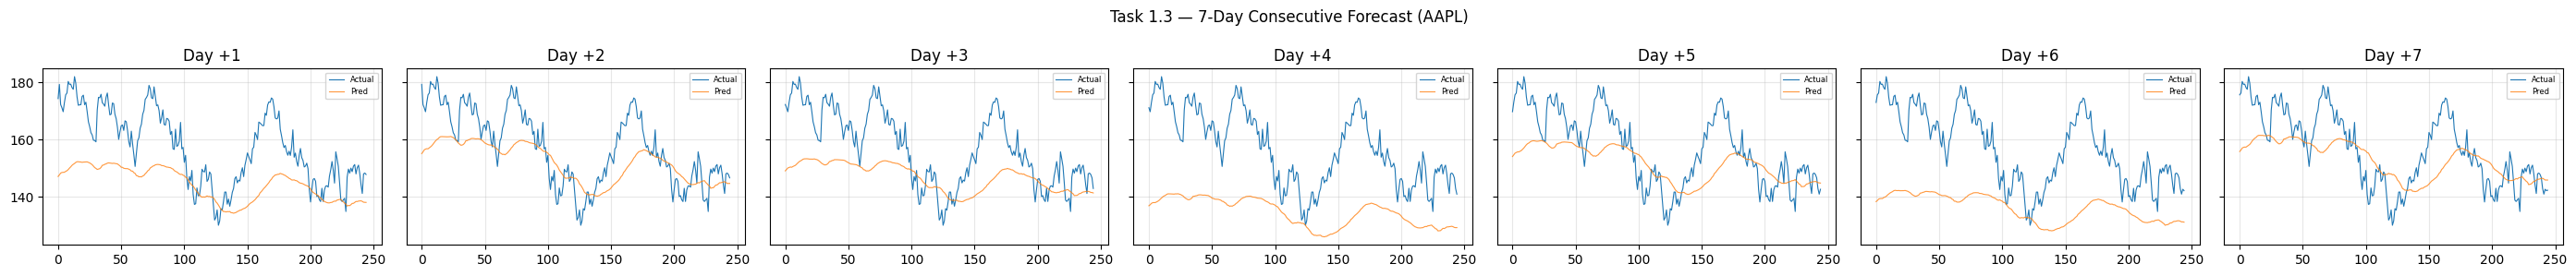

In [10]:
fig, axes = plt.subplots(1, K_DAYS, figsize=(4 * K_DAYS, 3), sharey=True)
for d in range(K_DAYS):
    axes[d].plot(y_true_13[:, d], linewidth=0.8, label='Actual')
    axes[d].plot(y_pred_13[:, d], linewidth=0.8, label='Pred', alpha=0.8)
    axes[d].set_title(f'Day +{d+1}')
    axes[d].legend(fontsize=6)
    axes[d].grid(alpha=0.3)
fig.suptitle(f'Task 1.3 — {K_DAYS}-Day Consecutive Forecast (AAPL)')
plt.tight_layout(); plt.show()

## Task 1 — Cross-Validation with TimeSeriesSplit

Standard k-fold CV shuffles the data, which is illegal for time-series. `TimeSeriesSplit` with 5 folds uses an expanding training window, so each fold's validation set is always strictly after its training set. The scaler is re-fitted inside every fold to prevent leakage from future data.

In [11]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

# X_all / y_all are the Task-1.1 windows (scaled with scaler_11)
# We rebuild raw feature arrays so we can re-scale per fold correctly
raw_data = df_aapl[FEATURES_AAPL].values.astype(np.float32)

for fold, (tr_idx, vl_idx) in enumerate(tscv.split(X_all)):
    # Re-fit scaler on this fold's training rows only
    fold_scaler = MinMaxScaler()
    # tr_idx indexes into the windowed array; the corresponding raw rows
    # start at 0 and end at tr_idx[-1] + WINDOW_SIZE
    raw_tr_end  = tr_idx[-1] + WINDOW_SIZE + 1
    fold_scaler.fit(raw_data[:raw_tr_end])
    fold_sc      = fold_scaler.transform(raw_data)
    fold_close   = fold_sc[:, CLOSE_IDX_AAPL]

    Xf_all, yf_all = build_windows(fold_sc, fold_close, WINDOW_SIZE)
    Xf_tr, yf_tr   = Xf_all[tr_idx], yf_all[tr_idx]
    Xf_vl, yf_vl   = Xf_all[vl_idx], yf_all[vl_idx]

    m = build_model(WINDOW_SIZE, N_FEAT_AAPL, 1)
    m.fit(Xf_tr, yf_tr,
          validation_data=(Xf_vl, yf_vl),
          epochs=30, batch_size=32,
          callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=0)],
          verbose=0)

    yp_sc = m.predict(Xf_vl, verbose=0).ravel()
    yp    = inverse_close(yp_sc,           fold_scaler, CLOSE_IDX_AAPL, N_FEAT_AAPL)
    yt    = inverse_close(yf_vl.ravel(),   fold_scaler, CLOSE_IDX_AAPL, N_FEAT_AAPL)

    mape = np.mean(np.abs((yt - yp) / (np.abs(yt) + 1e-8))) * 100
    rmse = np.sqrt(mean_squared_error(yt, yp))
    cv_scores.append(mape)
    print(f'  Fold {fold+1}: RMSE=${rmse:.3f}  MAPE={mape:.2f}%')

print(f'\nCV MAPE: {np.mean(cv_scores):.2f}% ± {np.std(cv_scores):.2f}%')

  Fold 1: RMSE=$1.102  MAPE=3.17%
  Fold 2: RMSE=$1.091  MAPE=2.50%
  Fold 3: RMSE=$2.349  MAPE=4.23%
  Fold 4: RMSE=$6.844  MAPE=6.29%
  Fold 5: RMSE=$7.945  MAPE=4.12%

CV MAPE: 4.06% ± 1.28%


---
# TASK 2 — Vietnam Stock Price Prediction
---

The same three subtasks (multi-feature, N-th day, K consecutive days) are applied to the Vietnam stock dataset. We select the **Banks** sector because it has the decent number of tickers with sufficient historical depth (≥ 2 400 trading days, roughly 10 years), which is the minimum needed to train and evaluate the CNN-LSTM reliably.

In [12]:
BASE_PATH    = '/content/drive/MyDrive/DL4AI-project'
HIST_PATH    = os.path.join(BASE_PATH, 'stock-historical-data')
OVERVIEW_CSV = os.path.join(BASE_PATH, 'ticker-overview.csv')
COMPANIES_CSV= os.path.join(BASE_PATH, 'companies.csv')
INDUSTRY_PATH = os.path.join(BASE_PATH, 'industry-analysis')

df_overview = pd.read_csv(OVERVIEW_CSV)
print('Industry path:', INDUSTRY_PATH)
print('Overview shape:', df_overview.shape)
print('Columns:', df_overview.columns.tolist())
df_overview.head(3)

Industry path: /content/drive/MyDrive/DL4AI-project/industry-analysis
Overview shape: (1629, 24)
Columns: ['Unnamed: 0', 'exchange', 'shortName', 'industryID', 'industryIDv2', 'industry', 'industryEn', 'establishedYear', 'noEmployees', 'noShareholders', 'foreignPercent', 'website', 'stockRating', 'deltaInWeek', 'deltaInMonth', 'deltaInYear', 'outstandingShare', 'issueShare', 'companyType', 'ticker', 'status', 'code', 'message', 'traceId']


,Unnamed: 0,exchange,shortName,industryID,industryIDv2,industry,industryEn,establishedYear,noEmployees,noShareholders,...,deltaInMonth,deltaInYear,outstandingShare,issueShare,companyType,ticker,status,code,message,traceId
0,0,UPCOM,Đầu tư Phát triển Máy Việt Nam,211.0,3353.0,Ô tô và phụ tùng,Automobiles & Parts,NaN,352.0,105.0,...,-0.098,NaN,20.5,20.5,CT,VVS,NaN,NaN,NaN,NaN
1,1,UPCOM,Xây dựng Công trình Tân Cảng,181.0,2357.0,Xây dựng và Vật liệu,Construction & Materials,NaN,110.0,0.0,...,-0.082,NaN,9.0,0.0,CT,XDC,NaN,NaN,NaN,NaN
2,2,UPCOM,Gang Thép Hà Nội,159.0,1757.0,Tài nguyên Cơ bản,Basic Resources,2013.0,0.0,109.0,...,0.064,-0.37,15.7,15.7,CT,HSV,NaN,NaN,NaN,NaN


In [13]:
print('Industries available:')
print(df_overview['industryEn'].value_counts().to_string())

Industries available:
industryEn
Construction & Materials       337
Industrial Goods & Services    268
Food & Beverage                151
Utilities                      145
Real Estate                    126
Basic Resources                110
Personal & Household Goods      77
Chemicals                       73
Health Care                     59
Financial Services              55
Travel & Leisure                50
Media                           41
Retail                          32
Technology                      30
Banks                           27
Automobiles & Parts             15
Oil & Gas                       12
Insurance                       12
Telecommunications               8


In [14]:
TARGET_SECTOR = 'Banks'

sector_tickers = df_overview[
    df_overview['industryEn'].str.contains(TARGET_SECTOR, case=False, na=False)
]['ticker'].tolist()

print(f'Tickers in [{TARGET_SECTOR}]: {len(sector_tickers)}')
print(sector_tickers)

Tickers in [Banks]: 27
['ABB', 'ACB', 'BID', 'CTG', 'EIB', 'BVB', 'HDB', 'KLB', 'LPB', 'MBB', 'MSB', 'NAB', 'BAB', 'NVB', 'OCB', 'PGB', 'SSB', 'SGB', 'SHB', 'STB', 'TCB', 'TPB', 'VAB', 'VCB', 'VIB', 'VPB', 'VBB']


The raw OHLCV (Open, High, Low, Close, Volume) features are extended with four technical indicators computed from historical price data: daily returns, 5-day moving average, 20-day moving average, and rolling volatility. These indicators are calculated in a point-in-time manner using only past and current observations, thereby avoiding look-ahead bias.

In addition, several financial and valuation ratios are incorporated from the industry-analysis files, including price-to-earnings ratio, price-to-book ratio, ROE, ROA, profit margins, debt-to-equity ratio, RSI, and relative strength metrics. Since the industry files provide only the latest available snapshot of these values, the same ratios are applied uniformly across all historical rows for each company. This introduces a limitation because the financial variables are not truly time-varying throughout the historical period.

In [15]:
MIN_ROWS = 2400
DATE_COL = 'TradingDate'

# Feature list for Vietnam tasks (Tasks 2, 3, 4)
FEATURES_VN = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Return',
    'MA5',
    'MA20',
    'Volatility',
    'priceToEarning',
    'priceToBook',
    'roe',
    'roa',
    'grossProfitMargin',
    'operatingProfitMargin',
    'postTaxMargin',
    'debtOnEquity',
    'rsi',
    'rs'
]

CLOSE_IDX_VN = FEATURES_VN.index('Close')   # = 3
N_FEAT_VN    = len(FEATURES_VN)              # = 19


def load_industry_data(ticker, industry_path):
    pattern = os.path.join(industry_path, f'{ticker}-*-Industry.csv')
    matches = glob.glob(pattern)
    if not matches:
        return None
    df = pd.read_csv(matches[0])
    df.columns = [c.strip() for c in df.columns]
    return df


def add_technical_indicators_vn(df):
    df = df.copy()
    df['Return']     = df['Close'].pct_change().fillna(0)
    df['MA5']        = df['Close'].rolling(5,  min_periods=1).mean()
    df['MA20']       = df['Close'].rolling(20, min_periods=1).mean()
    df['Volatility'] = df['Return'].rolling(20, min_periods=1).std().fillna(0)
    return df


def load_ticker_vn(ticker, hist_path, industry_path):
    pattern = os.path.join(hist_path, f'{ticker}-*-History.csv')
    matches = glob.glob(pattern)
    if not matches:
        return None

    df = pd.read_csv(matches[0])
    df.columns = [c.strip() for c in df.columns]
    if DATE_COL not in df.columns:
        return None

    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    df = df.dropna(subset=[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    df = add_technical_indicators_vn(df)

    # Append financial ratios from industry file (latest snapshot)
    df_ind = load_industry_data(ticker, industry_path)
    fund_cols = [
        'priceToEarning', 'priceToBook', 'roe', 'roa',
        'grossProfitMargin', 'operatingProfitMargin', 'postTaxMargin',
        'debtOnEquity', 'rsi', 'rs'
    ]
    if df_ind is not None:
        latest_row = df_ind.iloc[-1]
        for col in fund_cols:
            val = latest_row[col] if col in df_ind.columns else 0
            df[col] = 0 if pd.isna(val) else val
    else:
        for col in fund_cols:
            df[col] = 0

    needed_cols = [DATE_COL] + FEATURES_VN
    missing = [c for c in FEATURES_VN if c not in df.columns]
    if missing:
        print(f'{ticker} missing columns: {missing}')
        for col in missing:
            df[col] = 0

    df = df[needed_cols]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.ffill().bfill().fillna(0)
    return df


def scale_split_vn(df, features=FEATURES_VN, val=0.10, test=0.10):
    """Same as scale_split_aapl but for the Vietnam feature set."""
    data = df[features].values.astype(np.float32)
    n    = len(data)
    n_te = int(n * test)
    n_vl = int(n * val)
    n_tr = n - n_vl - n_te
    scaler   = MinMaxScaler()
    scaler.fit(data[:n_tr])
    full_sc  = scaler.transform(data)
    close_sc = full_sc[:, CLOSE_IDX_VN]
    return full_sc, close_sc, scaler, n_tr, n_vl, n_te


# Load all sector tickers
vn_data = {}
for ticker in sector_tickers:
    df_t = load_ticker_vn(ticker, HIST_PATH, INDUSTRY_PATH)
    if df_t is not None and len(df_t) >= MIN_ROWS:
        vn_data[ticker] = df_t
        print(
            f'{ticker:8s}: {len(df_t)} rows '
            f'({df_t[DATE_COL].min().date()} → {df_t[DATE_COL].max().date()})'
        )
    if df_t is not None:
        print(ticker, 'rows after cleaning =', len(df_t))

print(f'\nFinal selection: {len(vn_data)} companies')

ABB rows after cleaning = 539
ACB     : 4052 rows (2006-11-21 → 2023-02-28)
ACB rows after cleaning = 4052
BID rows after cleaning = 2267
CTG     : 3401 rows (2009-07-16 → 2023-02-28)
CTG rows after cleaning = 3401
EIB     : 3329 rows (2009-10-27 → 2023-02-28)
EIB rows after cleaning = 3329
BVB rows after cleaning = 660
HDB rows after cleaning = 1284
KLB rows after cleaning = 1418
LPB rows after cleaning = 1339
MBB     : 2827 rows (2011-11-01 → 2023-02-28)
MBB rows after cleaning = 2827
MSB rows after cleaning = 542
NAB rows after cleaning = 595
BAB rows after cleaning = 1285
NVB     : 3111 rows (2010-09-13 → 2023-02-28)
NVB rows after cleaning = 3111
OCB rows after cleaning = 517
PGB rows after cleaning = 541
SSB rows after cleaning = 483
SGB rows after cleaning = 591
SHB     : 3459 rows (2009-04-20 → 2023-02-28)
SHB rows after cleaning = 3459
STB     : 4147 rows (2006-07-12 → 2023-02-28)
STB rows after cleaning = 4147
TCB rows after cleaning = 1186
TPB rows after cleaning = 1215
VAB 

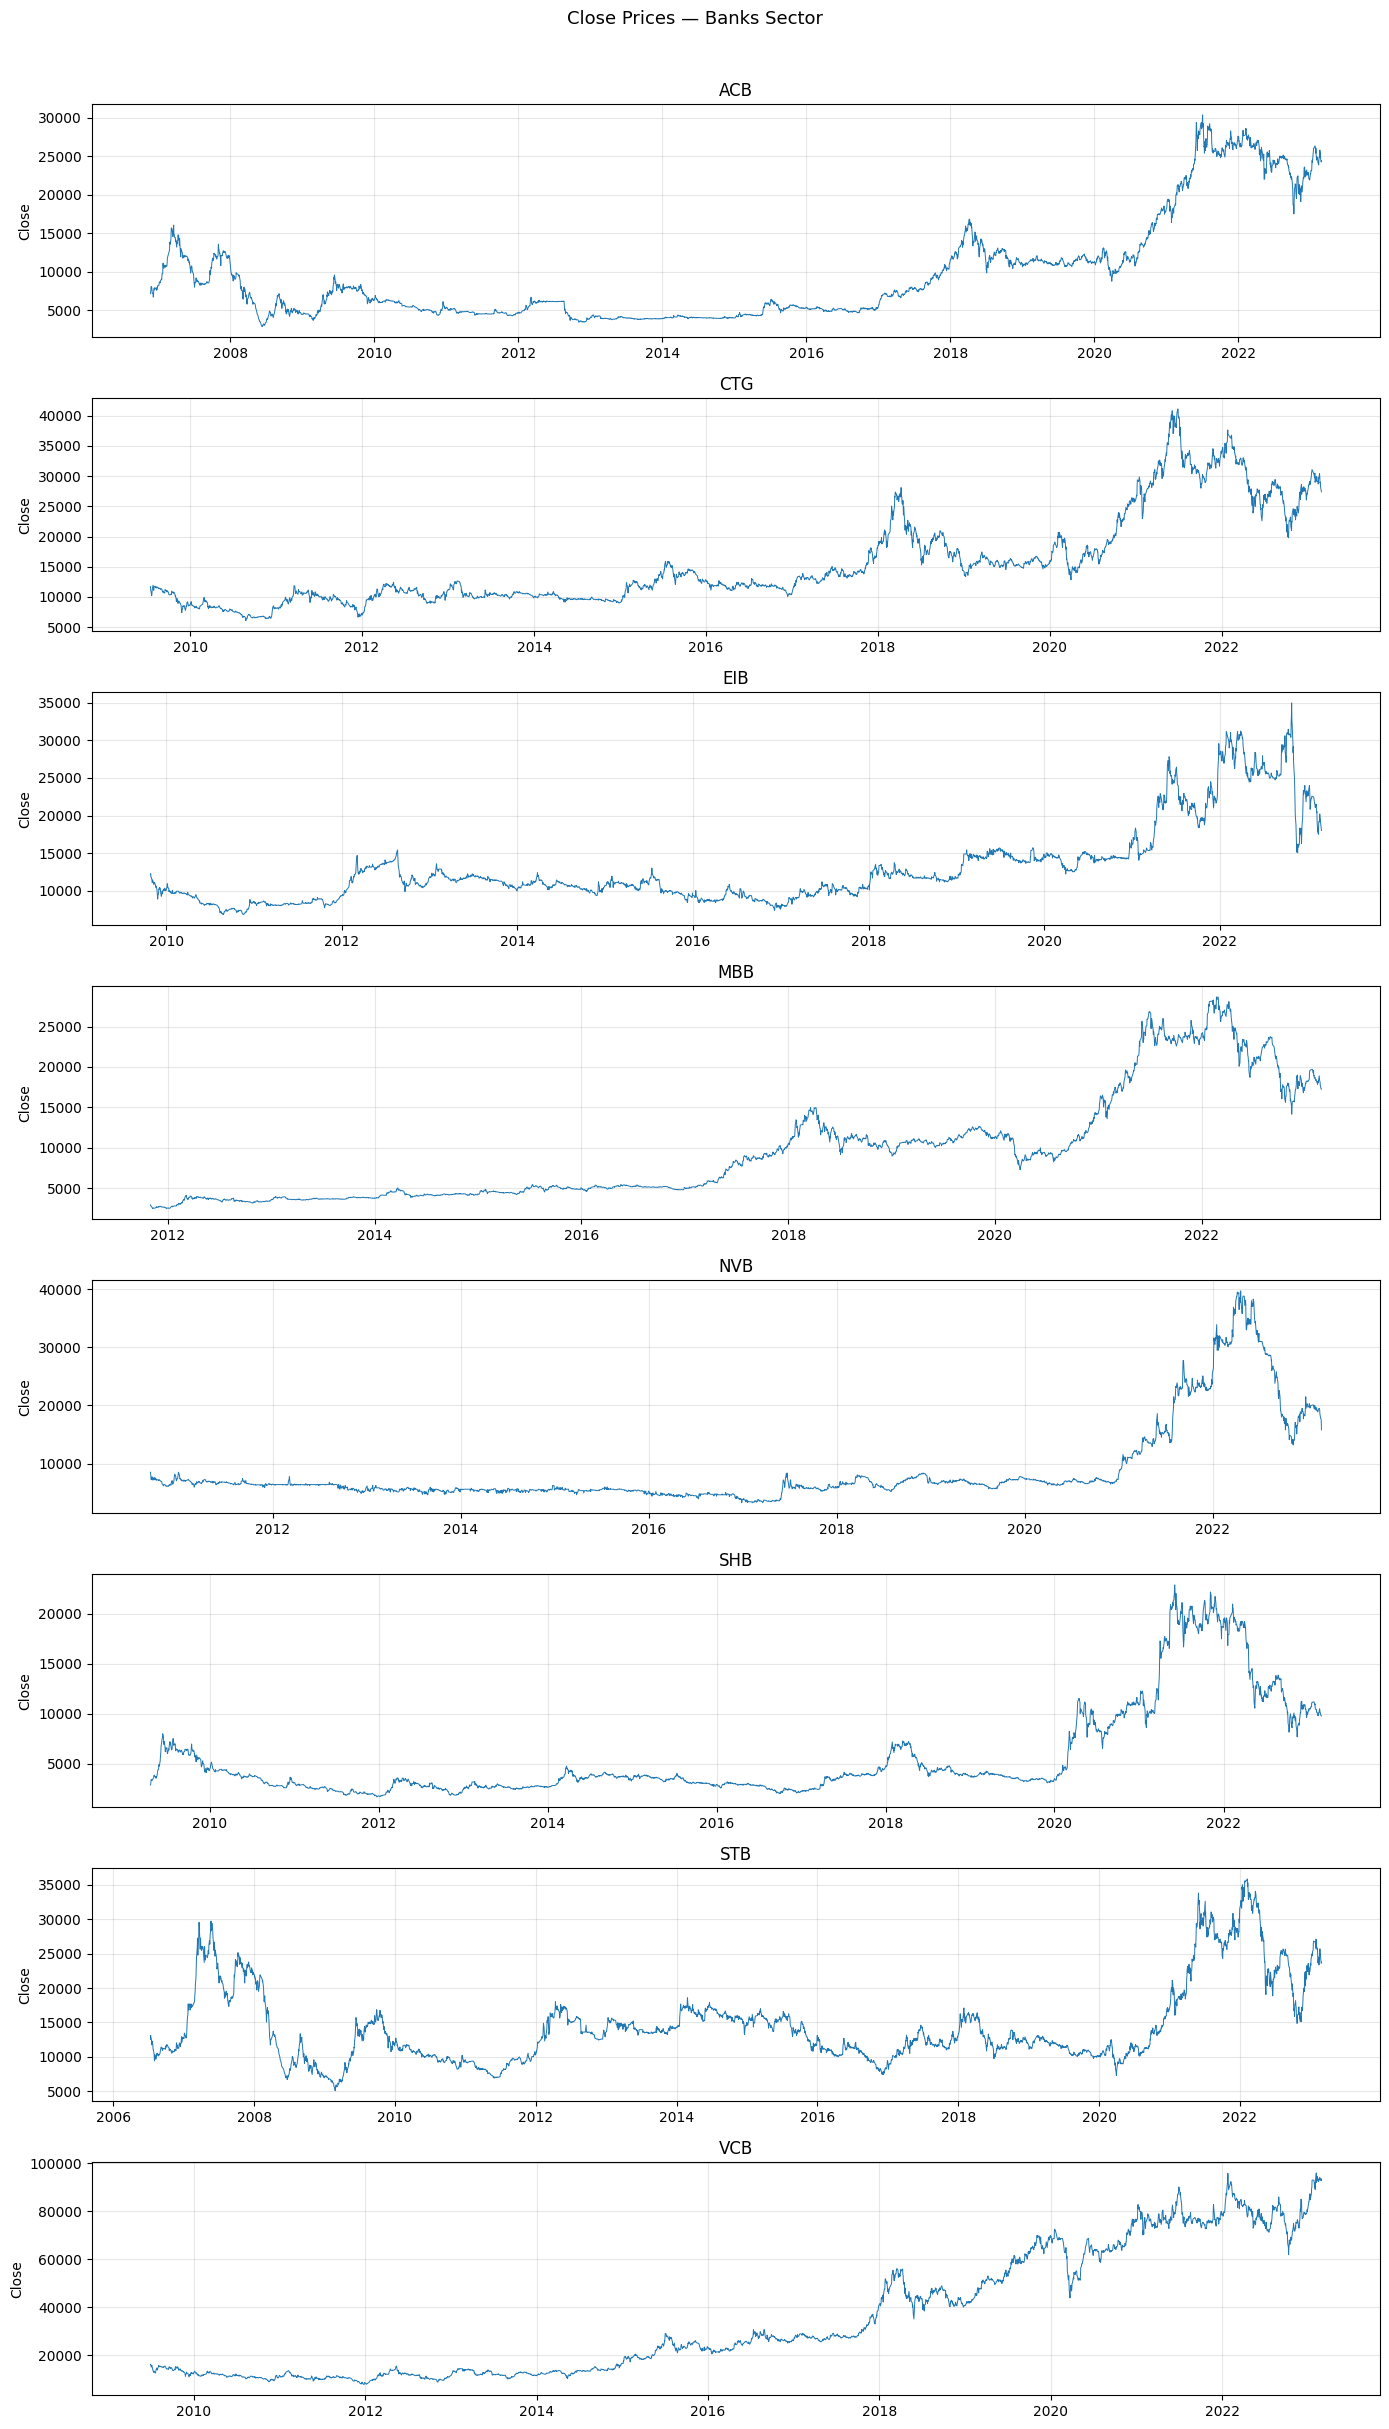

In [16]:
fig, axes = plt.subplots(len(vn_data), 1,
                          figsize=(14, 3 * len(vn_data)),
                          sharex=False)
if len(vn_data) == 1:
    axes = [axes]

for ax, (ticker, df_t) in zip(axes, vn_data.items()):
    ax.plot(df_t[DATE_COL], df_t['Close'], linewidth=0.7)
    ax.set_title(ticker); ax.set_ylabel('Close')
    ax.grid(alpha=0.3)

plt.suptitle(f'Close Prices — {TARGET_SECTOR} Sector', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## Task 2.1 — Vietnam Multi-Feature Extension

In [17]:
results_21 = {}
models_21  = {}
scalers_21 = {}

for ticker, df_t in vn_data.items():
    print(f'\n── {ticker} ──')

    full_sc, close_sc, scaler, n_tr, n_vl, n_te = scale_split_vn(df_t, FEATURES_VN)
    scalers_21[ticker] = scaler

    X_all, y_all = build_windows(full_sc, close_sc,
                                  WINDOW_SIZE, forecast_offset=1, k_days=1)
    X_tr, y_tr, X_vl, y_vl, X_te, y_te = chrono_split(X_all, y_all)
    print(f'  Train {X_tr.shape[0]} | Val {X_vl.shape[0]} | Test {X_te.shape[0]}')

    m = build_model(WINDOW_SIZE, N_FEAT_VN, n_outputs=1)
    m.fit(X_tr, y_tr,
          validation_data=(X_vl, y_vl),
          epochs=100, batch_size=32,
          callbacks=CALLBACKS, verbose=0)

    y_pred = inverse_close(m.predict(X_te, verbose=0), scaler, CLOSE_IDX_VN, N_FEAT_VN)
    y_true = inverse_close(y_te,                        scaler, CLOSE_IDX_VN, N_FEAT_VN)
    rmse, mae, mape = eval_metrics(y_true, y_pred, ticker)

    results_21[ticker] = dict(rmse=rmse, mae=mae, mape=mape,
                               y_true=y_true, y_pred=y_pred)
    models_21[ticker] = m

df_res21 = pd.DataFrame([
    {'Ticker': t, 'RMSE': v['rmse'], 'MAE': v['mae'], 'MAPE (%)': v['mape']}
    for t, v in results_21.items()
])
df_res21.loc[len(df_res21)] = ['AVERAGE',
    df_res21['RMSE'].mean(), df_res21['MAE'].mean(), df_res21['MAPE (%)'].mean()]
print('\n=== Task 2.1 Summary ===')
print(df_res21.to_string(index=False))


── ACB ──
  Train 3194 | Val 399 | Test 399
[ACB]  RMSE=$5096.119  MAE=$4956.360  MAPE=19.68%

── CTG ──
  Train 2673 | Val 334 | Test 334
[CTG]  RMSE=$3533.992  MAE=$3227.857  MAPE=10.83%

── EIB ──
  Train 2617 | Val 326 | Test 326
[EIB]  RMSE=$4571.260  MAE=$4052.102  MAPE=15.35%

── MBB ──
  Train 2215 | Val 276 | Test 276
[MBB]  RMSE=$5582.463  MAE=$5028.020  MAPE=22.16%

── NVB ──
  Train 2441 | Val 305 | Test 305
[NVB]  RMSE=$14645.697  MAE=$13060.553  MAPE=46.15%

── SHB ──
  Train 2721 | Val 339 | Test 339
[SHB]  RMSE=$1243.347  MAE=$953.578  MAPE=7.75%

── STB ──
  Train 3271 | Val 408 | Test 408
[STB]  RMSE=$1247.746  MAE=$1006.475  MAPE=4.17%

── VCB ──
  Train 2683 | Val 335 | Test 335
[VCB]  RMSE=$8378.195  MAE=$7350.574  MAPE=8.96%

=== Task 2.1 Summary ===
 Ticker         RMSE          MAE  MAPE (%)
    ACB  5096.119308  4956.360352 19.677240
    CTG  3533.991935  3227.856689 10.834701
    EIB  4571.259564  4052.101562 15.354675
    MBB  5582.462897  5028.020020 22.163

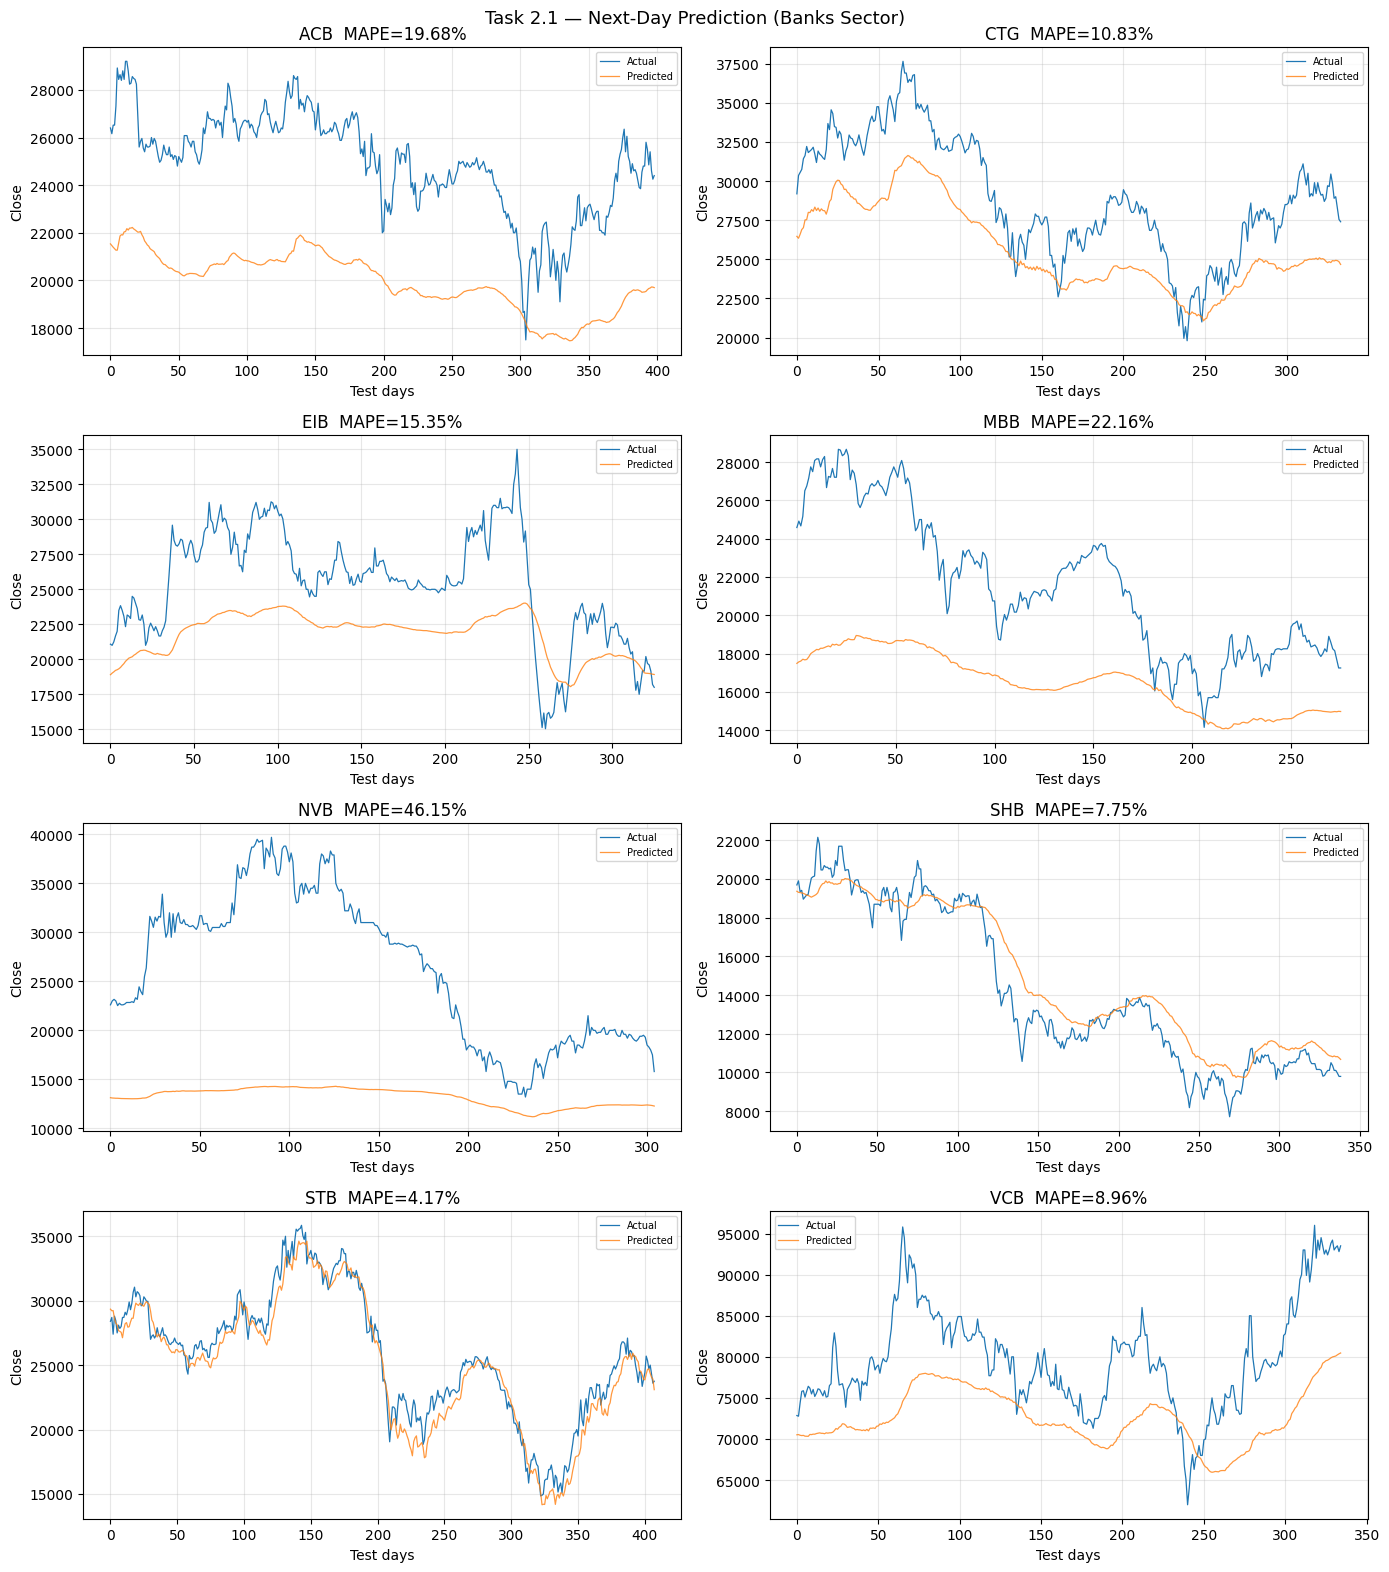

In [18]:
n_cols = 2
n_rows = (len(vn_data) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.ravel()

for i, (ticker, res) in enumerate(results_21.items()):
    axes[i].plot(res['y_true'], label='Actual',    linewidth=0.9)
    axes[i].plot(res['y_pred'], label='Predicted', linewidth=0.9, alpha=0.8)
    axes[i].set_title(f'{ticker}  MAPE={res["mape"]:.2f}%')
    axes[i].set_xlabel('Test days'); axes[i].set_ylabel('Close')
    axes[i].legend(fontsize=7); axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Task 2.1 — Next-Day Prediction ({TARGET_SECTOR} Sector)', fontsize=13)
plt.tight_layout(); plt.show()

## Task 2.2 — Vietnam N-th Day Forecast

In [19]:
N_DAY = 7
results_22 = {}

for ticker, df_t in vn_data.items():
    print(f'\n── {ticker} (Day +{N_DAY}) ──')

    full_sc, close_sc, scaler, _, _, _ = scale_split_vn(df_t, FEATURES_VN)

    X_all, y_all = build_windows(full_sc, close_sc,
                                  WINDOW_SIZE, forecast_offset=N_DAY, k_days=1)
    X_tr, y_tr, X_vl, y_vl, X_te, y_te = chrono_split(X_all, y_all)

    m = build_model(WINDOW_SIZE, N_FEAT_VN, n_outputs=1)
    m.fit(X_tr, y_tr,
          validation_data=(X_vl, y_vl),
          epochs=100, batch_size=32,
          callbacks=CALLBACKS, verbose=0)

    y_pred = inverse_close(m.predict(X_te, verbose=0), scaler, CLOSE_IDX_VN, N_FEAT_VN)
    y_true = inverse_close(y_te,                        scaler, CLOSE_IDX_VN, N_FEAT_VN)
    rmse, mae, mape = eval_metrics(y_true, y_pred, ticker)

    results_22[ticker] = dict(rmse=rmse, mae=mae, mape=mape,
                               y_true=y_true, y_pred=y_pred)

df_res22 = pd.DataFrame([
    {'Ticker': t, 'RMSE': v['rmse'], 'MAE': v['mae'], 'MAPE (%)': v['mape']}
    for t, v in results_22.items()
])
df_res22.loc[len(df_res22)] = ['AVERAGE',
    df_res22['RMSE'].mean(), df_res22['MAE'].mean(), df_res22['MAPE (%)'].mean()]
print(f'\n=== Task 2.2 Summary (Day +{N_DAY}) ===')
print(df_res22.to_string(index=False))


── ACB (Day +7) ──
[ACB]  RMSE=$4431.655  MAE=$4242.044  MAPE=16.79%

── CTG (Day +7) ──
[CTG]  RMSE=$4124.341  MAE=$3708.938  MAPE=12.40%

── EIB (Day +7) ──
[EIB]  RMSE=$5437.291  MAE=$4921.174  MAPE=18.82%

── MBB (Day +7) ──
[MBB]  RMSE=$4352.923  MAE=$3673.314  MAPE=15.83%

── NVB (Day +7) ──
[NVB]  RMSE=$14982.732  MAE=$13350.247  MAPE=47.09%

── SHB (Day +7) ──
[SHB]  RMSE=$1703.524  MAE=$1368.656  MAPE=9.11%

── STB (Day +7) ──
[STB]  RMSE=$6425.650  MAE=$5978.202  MAPE=22.51%

── VCB (Day +7) ──
[VCB]  RMSE=$12192.228  MAE=$11105.124  MAPE=13.58%

=== Task 2.2 Summary (Day +7) ===
 Ticker         RMSE          MAE  MAPE (%)
    ACB  4431.654770  4242.043945 16.791162
    CTG  4124.341160  3708.938477 12.400935
    EIB  5437.291237  4921.174316 18.816250
    MBB  4352.923156  3673.313965 15.827634
    NVB 14982.731927 13350.247070 47.088223
    SHB  1703.523921  1368.656128  9.109726
    STB  6425.650473  5978.201660 22.511929
    VCB 12192.228344 11105.124023 13.576220
AVERAG

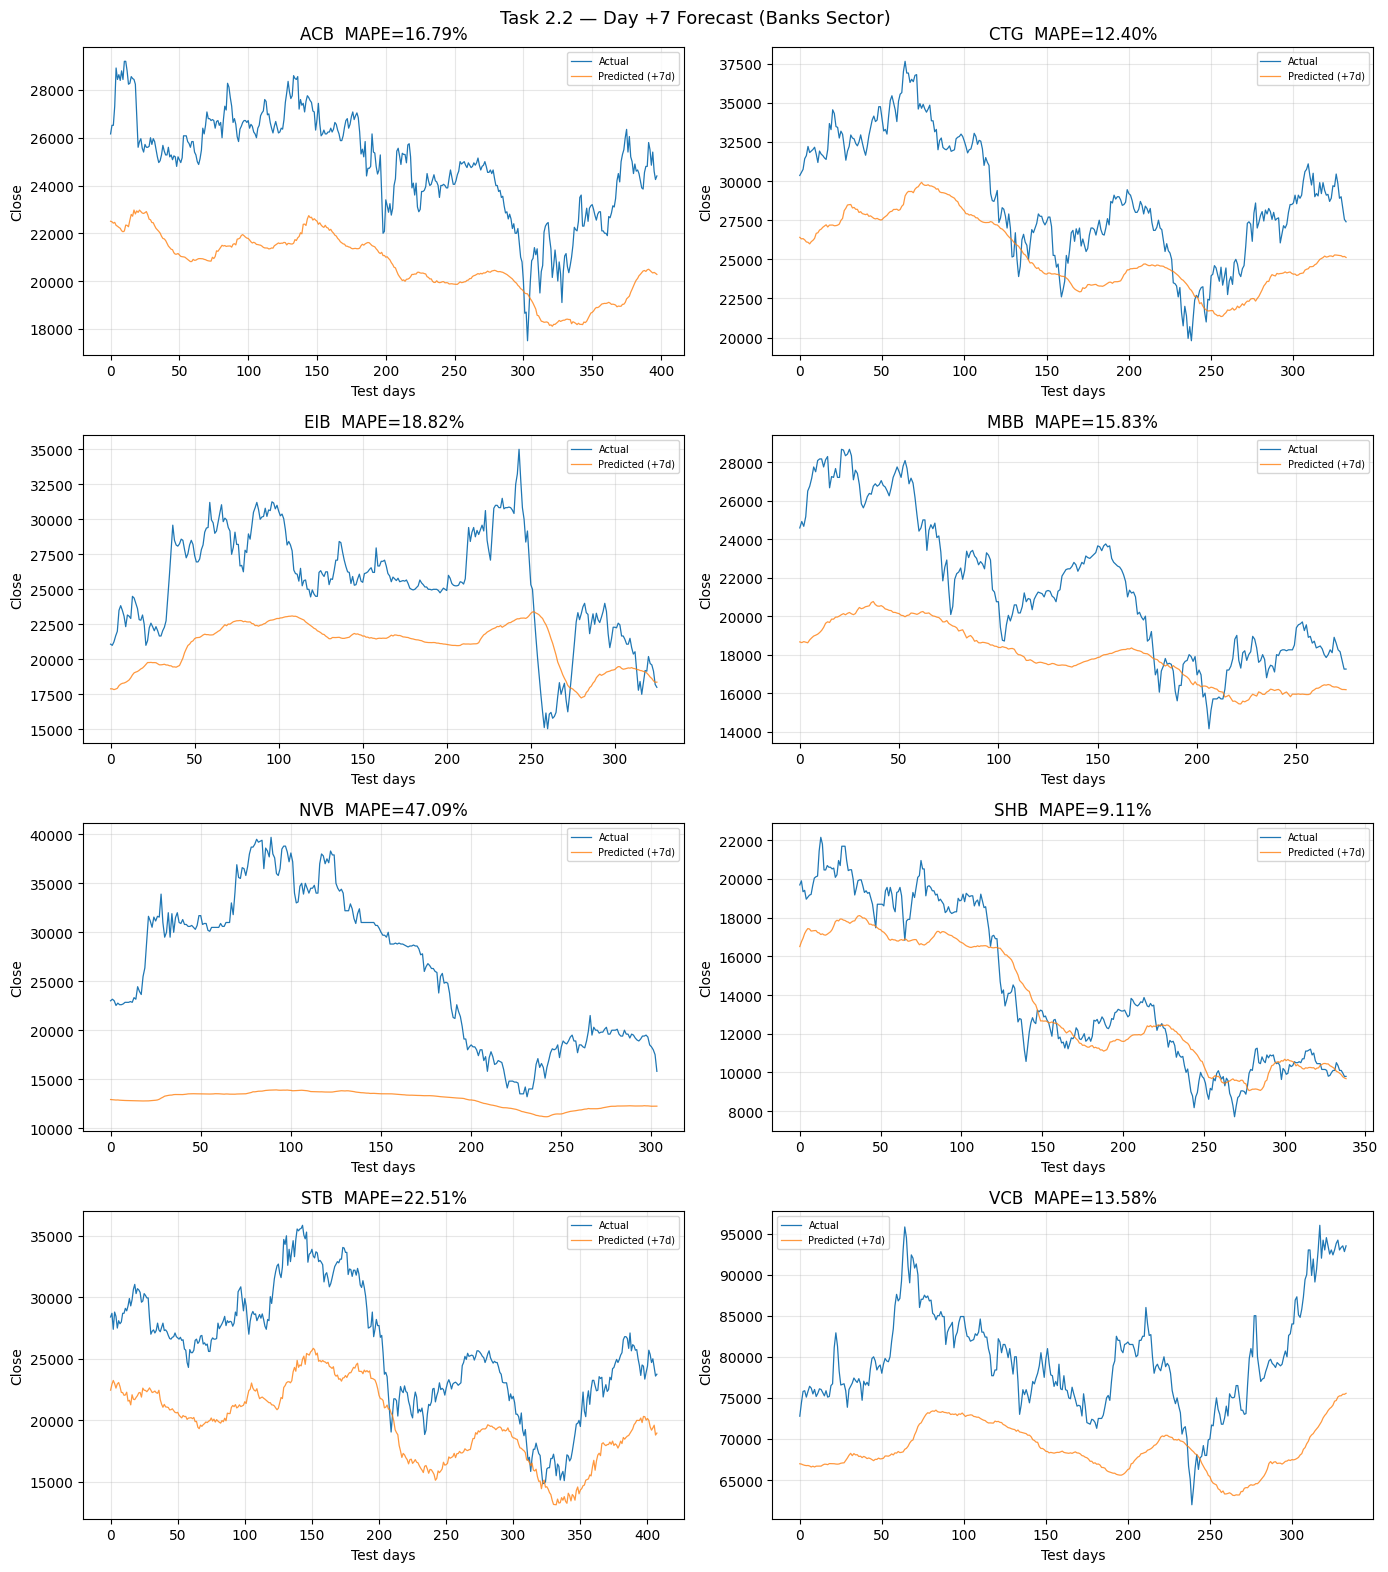

In [20]:
n_rows = (len(vn_data) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
axes = axes.ravel()

for i, (ticker, res) in enumerate(results_22.items()):
    axes[i].plot(res['y_true'], label='Actual',                  linewidth=0.9)
    axes[i].plot(res['y_pred'], label=f'Predicted (+{N_DAY}d)',  linewidth=0.9, alpha=0.8)
    axes[i].set_title(f'{ticker}  MAPE={res["mape"]:.2f}%')
    axes[i].set_xlabel('Test days'); axes[i].set_ylabel('Close')
    axes[i].legend(fontsize=7); axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Task 2.2 — Day +{N_DAY} Forecast ({TARGET_SECTOR} Sector)', fontsize=13)
plt.tight_layout(); plt.show()

## Task 2.3 — Vietnam K Consecutive Days Forecast

In [21]:
K_DAYS = 7
results_23 = {}

for ticker, df_t in vn_data.items():
    print(f'\n── {ticker} ({K_DAYS} consecutive days) ──')

    full_sc, close_sc, scaler, _, _, _ = scale_split_vn(df_t, FEATURES_VN)

    X_all, y_all = build_windows(full_sc, close_sc,
                                  WINDOW_SIZE, forecast_offset=1, k_days=K_DAYS)
    X_tr, y_tr, X_vl, y_vl, X_te, y_te = chrono_split(X_all, y_all)

    m = build_model(WINDOW_SIZE, N_FEAT_VN, n_outputs=K_DAYS)
    m.fit(X_tr, y_tr,
          validation_data=(X_vl, y_vl),
          epochs=100, batch_size=32,
          callbacks=CALLBACKS, verbose=0)

    y_pred_sc = m.predict(X_te, verbose=0)   # (N, K_DAYS)

    y_pred_k = np.stack(
        [inverse_close(y_pred_sc[:, d], scaler, CLOSE_IDX_VN, N_FEAT_VN)
         for d in range(K_DAYS)], axis=1)
    y_true_k = np.stack(
        [inverse_close(y_te[:, d], scaler, CLOSE_IDX_VN, N_FEAT_VN)
         for d in range(K_DAYS)], axis=1)

    rmse, mae, mape = eval_metrics(y_true_k, y_pred_k, f'{ticker} overall')

    per_horizon_mape = [
        np.mean(np.abs((y_true_k[:, d] - y_pred_k[:, d]) /
                        (np.abs(y_true_k[:, d]) + 1e-8))) * 100
        for d in range(K_DAYS)
    ]
    print('  Per-horizon MAPE: ' +
          '  '.join([f'+{d+1}d:{v:.1f}%' for d, v in enumerate(per_horizon_mape)]))

    results_23[ticker] = dict(rmse=rmse, mae=mae, mape=mape,
                               y_true_k=y_true_k, y_pred_k=y_pred_k,
                               per_horizon_mape=per_horizon_mape)

df_res23 = pd.DataFrame([
    {'Ticker': t, 'RMSE': v['rmse'], 'MAE': v['mae'], 'MAPE (%)': v['mape']}
    for t, v in results_23.items()
])
df_res23.loc[len(df_res23)] = ['AVERAGE',
    df_res23['RMSE'].mean(), df_res23['MAE'].mean(), df_res23['MAPE (%)'].mean()]
print(f'\n=== Task 2.3 Summary ({K_DAYS} consecutive days) ===')
print(df_res23.to_string(index=False))


── ACB (7 consecutive days) ──
[ACB overall]  RMSE=$3856.196  MAE=$3635.900  MAPE=14.38%
  Per-horizon MAPE: +1d:13.3%  +2d:9.4%  +3d:16.3%  +4d:15.5%  +5d:15.7%  +6d:16.2%  +7d:14.3%

── CTG (7 consecutive days) ──
[CTG overall]  RMSE=$4419.878  MAE=$4007.091  MAPE=13.40%
  Per-horizon MAPE: +1d:12.0%  +2d:13.8%  +3d:11.7%  +4d:12.1%  +5d:16.1%  +6d:14.7%  +7d:13.3%

── EIB (7 consecutive days) ──
[EIB overall]  RMSE=$6889.146  MAE=$6254.635  MAPE=23.48%
  Per-horizon MAPE: +1d:22.2%  +2d:21.8%  +3d:24.4%  +4d:23.7%  +5d:21.2%  +6d:26.8%  +7d:24.3%

── MBB (7 consecutive days) ──
[MBB overall]  RMSE=$5807.514  MAE=$5022.696  MAPE=21.79%
  Per-horizon MAPE: +1d:16.1%  +2d:26.6%  +3d:19.5%  +4d:22.9%  +5d:21.0%  +6d:17.4%  +7d:29.1%

── NVB (7 consecutive days) ──
[NVB overall]  RMSE=$16637.588  MAE=$15040.574  MAPE=53.63%
  Per-horizon MAPE: +1d:55.8%  +2d:50.4%  +3d:48.6%  +4d:57.5%  +5d:54.7%  +6d:52.9%  +7d:55.5%

── SHB (7 consecutive days) ──
[SHB overall]  RMSE=$3209.859  MAE=$2

---
# TASK 3 — Trading Signal Identification (Vietnam)
---

Price prediction is reframed as **binary classification**: given the last 60 trading days, does the price rise ≥ 2 % (buy signal) or fall ≥ 2 % (sell signal) at any point within the next 10 trading days?

Key design choices:
- **Separate buy and sell models.** The two signals are not mutually exclusive (a volatile stock can trigger both), so training them jointly with a single output would conflate distinct market dynamics.
- **Class weighting.** Buy/sell events are rare relative to "no signal" days, so we weight the positive class by the inverse class frequency to prevent the model from predicting the majority class exclusively.
- **14 technical indicators** on top of OHLCV. RSI, MACD, Bollinger Bands, and rolling statistics capture momentum and mean-reversion effects that are standard in quantitative trading.
- **Ticker: VCB** (Vietcombank), chosen as it is the most liquid and long-running stock in the Banks sector.

In [22]:
TICKER = 'VCB'

matches = glob.glob(os.path.join(HIST_PATH, f'{TICKER}-*-History.csv'))
assert len(matches) > 0, f'No file found for {TICKER}'
print('Loading:', matches[0])

df_vcb = pd.read_csv(matches[0])
df_vcb.columns = [c.strip() for c in df_vcb.columns]
df_vcb['TradingDate'] = pd.to_datetime(df_vcb['TradingDate'], errors='coerce')
df_vcb = df_vcb.dropna(subset=['TradingDate'])
df_vcb = df_vcb.sort_values('TradingDate').reset_index(drop=True)

print(f'Rows: {len(df_vcb)}')
print(f'Date range: {df_vcb["TradingDate"].min().date()} → {df_vcb["TradingDate"].max().date()}')
df_vcb[['TradingDate', 'Open', 'High', 'Low', 'Close', 'Volume']].head()

Loading: /content/drive/MyDrive/DL4AI-project/stock-historical-data/VCB-VNINDEX-History.csv
Rows: 3413
Date range: 2009-06-30 → 2023-02-28


,TradingDate,Open,High,Low,Close,Volume
0,2009-06-30,16245.0,16245.0,16245.0,16245.0,294070
1,2009-07-01,17057.0,17058.0,16110.0,16381.0,6248390
2,2009-07-02,16110.0,16245.0,15568.0,15704.0,1515670
3,2009-07-03,15298.0,15433.0,15162.0,15162.0,899720
4,2009-07-06,15839.0,15839.0,15162.0,15839.0,1571740


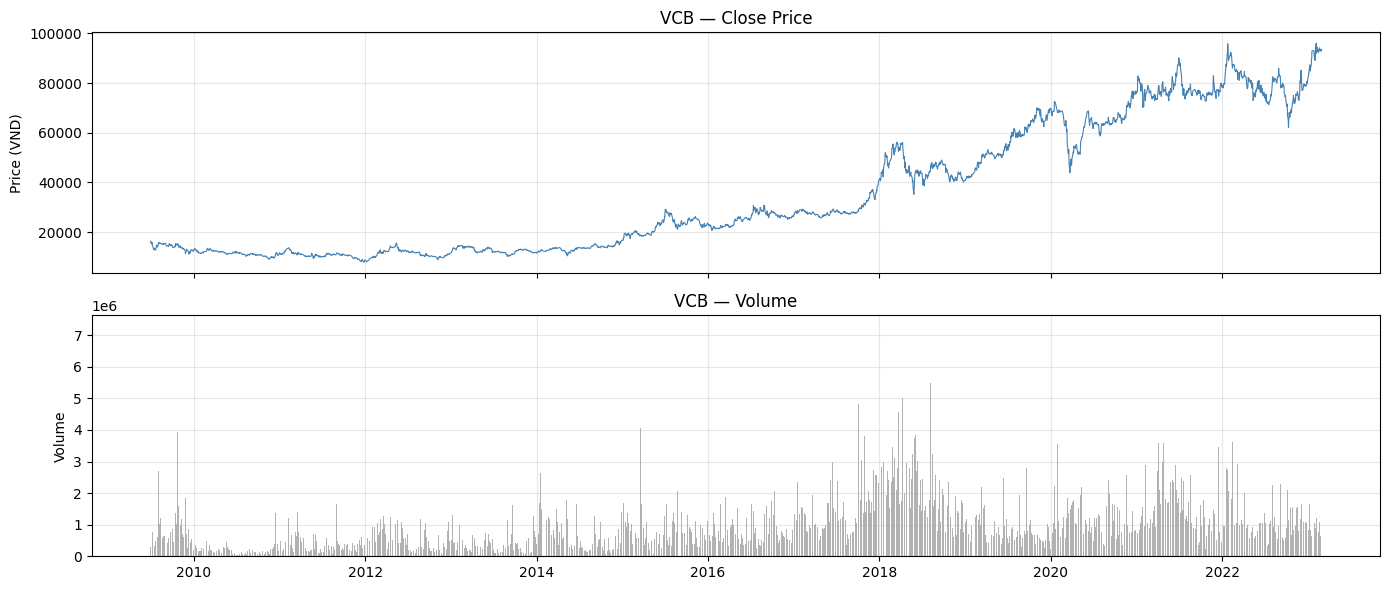

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax1.plot(df_vcb['TradingDate'], df_vcb['Close'], linewidth=0.8, color='steelblue')
ax1.set_title('VCB — Close Price'); ax1.set_ylabel('Price (VND)'); ax1.grid(alpha=0.3)

ax2.bar(df_vcb['TradingDate'], df_vcb['Volume'], width=1, color='grey', alpha=0.6)
ax2.set_title('VCB — Volume'); ax2.set_ylabel('Volume'); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [24]:
# ── Technical indicator helpers (Task 3) ─────────────────────
def sma_t3(s, w):     return s.rolling(w).mean()
def ema_t3(s, span):  return s.ewm(span=span, adjust=False).mean()

def rsi_t3(s, period=14):
    delta = s.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    return 100 - 100 / (1 + gain / (loss + 1e-8))

def macd_t3(s, fast=12, slow=26, signal=9):
    m   = ema_t3(s, fast) - ema_t3(s, slow)
    sig = ema_t3(m, signal)
    return m, sig, m - sig

def bollinger_t3(s, w=20, n_std=2):
    mid = sma_t3(s, w)
    std = s.rolling(w).std()
    return mid + n_std * std, mid, mid - n_std * std


def add_indicators_t3(df):
    d = df.copy()
    c = d['Close']; v = d['Volume']

    d['SMA_5']     = sma_t3(c, 5)
    d['SMA_20']    = sma_t3(c, 20)
    d['SMA_60']    = sma_t3(c, 60)
    d['EMA_12']    = ema_t3(c, 12)
    d['EMA_26']    = ema_t3(c, 26)
    d['RSI_14']    = rsi_t3(c, 14)
    d['Return_1']  = c.pct_change(1)
    d['Return_5']  = c.pct_change(5)

    ml, ms, mh     = macd_t3(c)
    d['MACD']      = ml
    d['MACD_sig']  = ms
    d['MACD_hist'] = mh

    bu, bm, bl     = bollinger_t3(c)
    d['BB_width']  = (bu - bl) / (bm + 1e-8)
    d['BB_pos']    = (c - bl)  / (bu - bl + 1e-8)
    d['Vol_change']= v.pct_change()

    d = d.replace([np.inf, -np.inf], np.nan)
    d = d.ffill().dropna().reset_index(drop=True)
    return d


BASE_COLS_T3 = ['Open', 'High', 'Low', 'Close', 'Volume']
IND_COLS_T3  = ['SMA_5', 'SMA_20', 'SMA_60', 'EMA_12', 'EMA_26',
                'RSI_14', 'Return_1', 'Return_5',
                'MACD', 'MACD_sig', 'MACD_hist',
                'BB_width', 'BB_pos', 'Vol_change']
ALL_FEAT_T3  = BASE_COLS_T3 + IND_COLS_T3

df_feat_vcb = add_indicators_t3(df_vcb)
print(f'Rows after indicator warm-up: {len(df_feat_vcb)}')
print(f'Total features: {len(ALL_FEAT_T3)}')
df_feat_vcb[ALL_FEAT_T3].describe().round(4)

Rows after indicator warm-up: 3354
Total features: 19


,Open,High,Low,Close,Volume,SMA_5,SMA_20,SMA_60,EMA_12,EMA_26,RSI_14,Return_1,Return_5,MACD,MACD_sig,MACD_hist,BB_width,BB_pos,Vol_change
count,3354.0000,3354.0000,3354.0000,3354.0000,3.354000e+03,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000
mean,35380.2364,35830.6377,34953.3971,35402.5581,9.518335e+05,35355.9256,35180.1187,34746.2257,35274.1875,35116.7480,51.8265,0.0007,0.0037,157.4395,154.9717,2.4678,0.1284,0.5291,0.1994
std,25641.5087,25963.4529,25309.4425,25660.4296,8.077655e+05,25616.0081,25455.5061,25092.8194,25529.5750,25378.7399,17.1533,0.0196,0.0444,885.1342,828.7023,272.3874,0.0700,0.3257,0.9219
min,7819.0000,7980.0000,7819.0000,7819.0000,0.000000e+00,8101.2000,8306.6000,8939.9833,8273.2876,8481.5606,0.0000,-0.0699,-0.1881,-5382.0321,-4611.0714,-1516.7896,0.0243,-0.4002,-1.0000
25%,12458.5000,12622.0000,12346.7500,12454.0000,3.840100e+05,12445.2000,12425.6125,12471.6167,12448.9922,12464.4608,40.3256,-0.0098,-0.0217,-197.5819,-203.6794,-82.3625,0.0756,0.2759,-0.3148
50%,25819.0000,26113.0000,25637.0000,25819.0000,7.417900e+05,25791.7000,25810.2500,25105.7167,25802.0557,25911.2634,51.4002,0.0000,0.0012,45.4054,46.0664,5.1426,0.1116,0.5290,-0.0034
75%,59140.0000,59980.0000,58439.0000,59200.0000,1.258095e+06,59318.1500,59192.5125,57414.7667,59234.8894,58600.5778,64.2029,0.0102,0.0275,468.8617,446.0996,97.5843,0.1624,0.7745,0.4262
max,95800.0000,96300.0000,94000.0000,96000.0000,7.265480e+06,93940.0000,93045.0000,86165.0000,93109.1105,91551.3588,98.6894,0.0700,0.2671,4045.7807,3342.2633,1343.1852,0.5100,1.4872,16.8285


In [25]:
HORIZON  = 10   # trading days to look ahead
BUY_THR  = 0.02 # +2 % threshold for a buy signal
SELL_THR = 0.02 # -2 % threshold for a sell signal

def make_labels(close_arr, horizon=HORIZON, buy_thr=BUY_THR, sell_thr=SELL_THR):
    n    = len(close_arr)
    buy  = np.zeros(n - horizon, dtype=np.int32)
    sell = np.zeros(n - horizon, dtype=np.int32)
    for i in range(n - horizon):
        future  = close_arr[i + 1 : i + 1 + horizon]
        max_ret = (future.max() - close_arr[i]) / (close_arr[i] + 1e-8)
        min_ret = (future.min() - close_arr[i]) / (close_arr[i] + 1e-8)
        if max_ret >=  buy_thr:  buy[i]  = 1
        if min_ret <= -sell_thr: sell[i] = 1
    return buy, sell


close_arr = df_feat_vcb['Close'].values
buy_lbl, sell_lbl = make_labels(close_arr)

print(f'Total labelled days : {len(buy_lbl)}')
print(f'Buy  signals  : {buy_lbl.sum():4d}  ({buy_lbl.mean()*100:.1f}%)')
print(f'Sell signals  : {sell_lbl.sum():4d}  ({sell_lbl.mean()*100:.1f}%)')
print(f'Both signals  : {((buy_lbl==1)&(sell_lbl==1)).sum():4d}  (volatile days)')
print(f'No signal     : {((buy_lbl==0)&(sell_lbl==0)).sum():4d}')

Total labelled days : 3344
Buy  signals  : 1910  (57.1%)
Sell signals  : 1764  (52.8%)
Both signals  :  548  (volatile days)
No signal     :  218


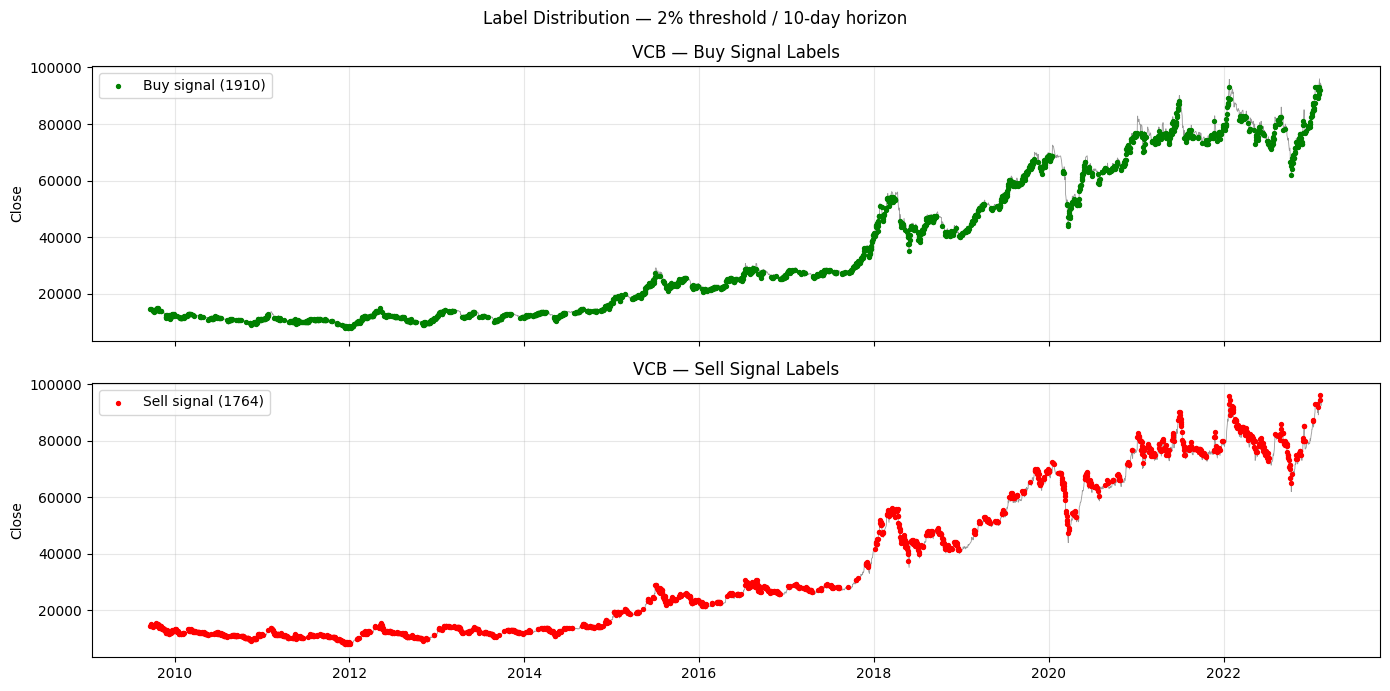

In [26]:
dates  = df_feat_vcb['TradingDate'].values[:len(buy_lbl)]
prices = df_feat_vcb['Close'].values[:len(buy_lbl)]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(dates, prices, color='grey', linewidth=0.6, alpha=0.8)
buy_idx = np.where(buy_lbl == 1)[0]
axes[0].scatter(dates[buy_idx], prices[buy_idx],
                color='green', s=8, zorder=5, label=f'Buy signal ({len(buy_idx)})')
axes[0].set_title('VCB — Buy Signal Labels'); axes[0].set_ylabel('Close')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(dates, prices, color='grey', linewidth=0.6, alpha=0.8)
sell_idx = np.where(sell_lbl == 1)[0]
axes[1].scatter(dates[sell_idx], prices[sell_idx],
                color='red', s=8, zorder=5, label=f'Sell signal ({len(sell_idx)})')
axes[1].set_title('VCB — Sell Signal Labels'); axes[1].set_ylabel('Close')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'Label Distribution — {BUY_THR*100:.0f}% threshold / {HORIZON}-day horizon')
plt.tight_layout(); plt.show()

In [27]:
WIN_CLS = 60
VAL_R   = 0.10
TEST_R  = 0.10

def make_cls_windows(feat_arr, labels, win):
    """
    Each input window covers days [i, i+win-1].
    The label at position i+win-1 is the signal whose reference
    price is the last day of that window — ensuring alignment.
    """
    X, y = [], []
    for i in range(len(labels) - win + 1):
        X.append(feat_arr[i : i + win])
        y.append(labels[i + win - 1])   # label aligned with window end
    return np.array(X, np.float32), np.array(y, np.int32)


def chrono_split_cls(X, y, val=VAL_R, test=TEST_R):
    n = len(X)
    n_te = int(n * test); n_vl = int(n * val); n_tr = n - n_vl - n_te
    return (X[:n_tr],          y[:n_tr],
            X[n_tr:n_tr+n_vl], y[n_tr:n_tr+n_vl],
            X[n_tr+n_vl:],     y[n_tr+n_vl:])


feat_arr_vcb = df_feat_vcb[ALL_FEAT_T3].values[:len(buy_lbl)]
n     = len(feat_arr_vcb)
n_te  = int(n * TEST_R); n_vl = int(n * VAL_R); n_tr = n - n_vl - n_te

scaler_cls = MinMaxScaler()
scaler_cls.fit(feat_arr_vcb[:n_tr])
feat_sc_vcb = scaler_cls.transform(feat_arr_vcb)

X_all_buy,  y_all_buy  = make_cls_windows(feat_sc_vcb, buy_lbl,  WIN_CLS)
X_all_sell, y_all_sell = make_cls_windows(feat_sc_vcb, sell_lbl, WIN_CLS)

X_tr_b, y_tr_b, X_vl_b, y_vl_b, X_te_b, y_te_b = chrono_split_cls(X_all_buy,  y_all_buy)
X_tr_s, y_tr_s, X_vl_s, y_vl_s, X_te_s, y_te_s = chrono_split_cls(X_all_sell, y_all_sell)

print(f'Window size : {WIN_CLS} days')
print(f'Features    : {len(ALL_FEAT_T3)}')
print(f'\nBUY  — Train={X_tr_b.shape[0]} Val={X_vl_b.shape[0]} Test={X_te_b.shape[0]}')
print(f'  Train positives: {y_tr_b.sum()} ({y_tr_b.mean()*100:.1f}%)')
print(f'  Test  positives: {y_te_b.sum()} ({y_te_b.mean()*100:.1f}%)')
print(f'\nSELL — Train={X_tr_s.shape[0]} Val={X_vl_s.shape[0]} Test={X_te_s.shape[0]}')
print(f'  Train positives: {y_tr_s.sum()} ({y_tr_s.mean()*100:.1f}%)')
print(f'  Test  positives: {y_te_s.sum()} ({y_te_s.mean()*100:.1f}%)')

Window size : 60 days
Features    : 19

BUY  — Train=2629 Val=328 Test=328
  Train positives: 1509 (57.4%)
  Test  positives: 189 (57.6%)

SELL — Train=2629 Val=328 Test=328
  Train positives: 1393 (53.0%)
  Test  positives: 165 (50.3%)


In [52]:
def build_cls_model(window_size, n_features):
    model = Sequential([
        Conv1D(32, 3, activation='relu', padding='same',
               input_shape=(window_size, n_features)),
        MaxPooling1D(2),
        Conv1D(64, 3, activation='relu', padding='same'),
        MaxPooling1D(2),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model_buy = build_cls_model(WIN_CLS, len(ALL_FEAT_T3))
model_buy.summary()

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_72 (Conv1D)              │ (None, 60, 32)         │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_72 (MaxPooling1D) │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_73 (Conv1D)              │ (None, 30, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_73 (MaxPooling1D) │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_37 (LSTM)                  │ (None, 15, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_38 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,593 (213.25 KB)

 Trainable params: 54,593 (213.25 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3.1 — Buying Signal Identification

In [53]:
pos_b = y_tr_b.sum()
neg_b = len(y_tr_b) - pos_b
cw_buy = {0: 1.0, 1: float(neg_b) / float(pos_b + 1e-8)}
print(f'Buy class weights: {cw_buy}')

CALLBACKS_CLS = [
    EarlyStopping(patience=12, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(patience=4, factor=0.5, verbose=0)
]

history_buy = model_buy.fit(
    X_tr_b, y_tr_b,
    validation_data=(X_vl_b, y_vl_b),
    epochs=100, batch_size=32,
    class_weight=cw_buy,
    callbacks=CALLBACKS_CLS, verbose=1
)

Buy class weights: {0: 1.0, 1: 0.7422133863436567}
Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.5295 - auc: 0.4961 - loss: 0.5919 - val_accuracy: 0.5762 - val_auc: 0.5499 - val_loss: 0.6917 - learning_rate: 0.0010
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4914 - auc: 0.4930 - loss: 0.5916 - val_accuracy: 0.5579 - val_auc: 0.4822 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.5131 - auc: 0.5209 - loss: 0.5902 - val_accuracy: 0.5579 - val_auc: 0.4699 - val_loss: 0.6896 - learning_rate: 0.0010
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5561 - auc: 0.5462 - loss: 0.5882 - val_accuracy: 0.4421 - val_auc: 0.5631 - val_loss: 0.7017 - learning_rate: 0.0010
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5747 - auc: 0.5741 - loss: 0.5820 - val_accuracy: 0.5579 - val_auc: 0.5000 - val_loss: 0.6901 - learning_rate: 0.0010
Epoch 6/100
83/83 ━━━━━━━━━━━

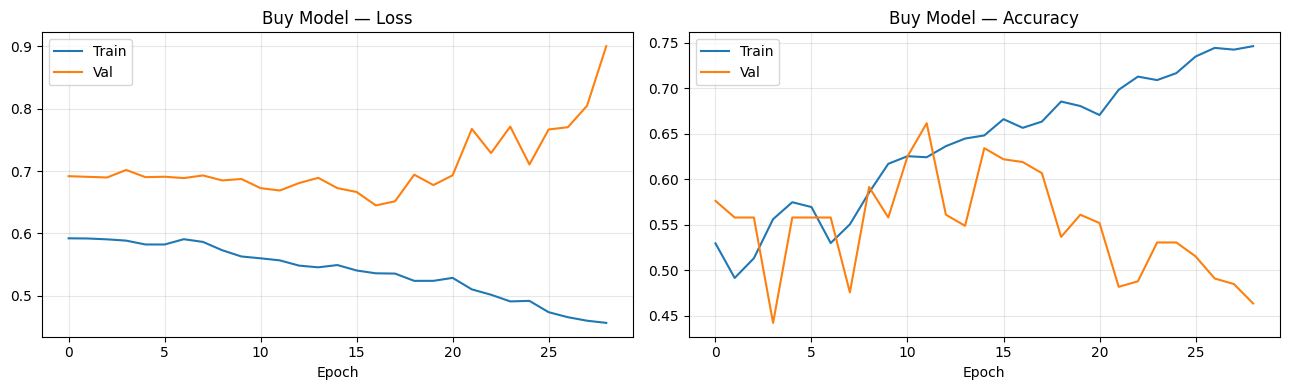

In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history_buy.history['loss'],     label='Train')
ax1.plot(history_buy.history['val_loss'], label='Val')
ax1.set_title('Buy Model — Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history_buy.history['accuracy'],     label='Train')
ax2.plot(history_buy.history['val_accuracy'], label='Val')
ax2.set_title('Buy Model — Accuracy'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [55]:
buy_probs = model_buy.predict(X_te_b, verbose=0).ravel()
buy_preds = (buy_probs >= 0.5).astype(int)

print('=== Task 3.1 — Buy Signal (VCB) ===')
print(classification_report(y_te_b, buy_preds,
                             target_names=['No signal', 'Buy'],
                             zero_division=0))
buy_auc = roc_auc_score(y_te_b, buy_probs)
print(f'ROC-AUC : {buy_auc:.4f}')
print(f'F1      : {f1_score(y_te_b, buy_preds, zero_division=0):.4f}')

=== Task 3.1 — Buy Signal (VCB) ===
              precision    recall  f1-score   support

   No signal       0.50      0.35      0.41       139
         Buy       0.61      0.75      0.67       189

    accuracy                           0.58       328
   macro avg       0.55      0.55      0.54       328
weighted avg       0.56      0.58      0.56       328

ROC-AUC : 0.5329
F1      : 0.6698


## Task 3.2 — Selling Signal Identification

In [66]:
pos_s = y_tr_s.sum()
neg_s = len(y_tr_s) - pos_s
cw_sell = {0: 1.0, 1: float(neg_s) / float(pos_s + 1e-8)}
print(f'Sell class weights: {cw_sell}')

model_sell = build_cls_model(WIN_CLS, len(ALL_FEAT_T3))
history_sell = model_sell.fit(
    X_tr_s, y_tr_s,
    validation_data=(X_vl_s, y_vl_s),
    epochs=150, batch_size=32,
    class_weight=cw_sell,
    callbacks=CALLBACKS_CLS, verbose=1
)

Sell class weights: {0: 1.0, 1: 0.8872936109053318}
Epoch 1/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - accuracy: 0.5299 - auc: 0.5221 - loss: 0.6524 - val_accuracy: 0.4787 - val_auc: 0.6336 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 2/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5527 - auc: 0.5566 - loss: 0.6479 - val_accuracy: 0.5213 - val_auc: 0.5973 - val_loss: 0.7164 - learning_rate: 0.0010
Epoch 3/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5630 - auc: 0.5560 - loss: 0.6475 - val_accuracy: 0.5213 - val_auc: 0.6057 - val_loss: 0.6903 - learning_rate: 0.0010
Epoch 4/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5633 - auc: 0.5604 - loss: 0.6461 - val_accuracy: 0.5244 - val_auc: 0.6019 - val_loss: 0.6842 - learning_rate: 0.0010
Epoch 5/150
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5770 - auc: 0.5779 - loss: 0.6406 - val_accuracy: 0.5213 - val_auc: 0.5696 - val_loss: 0.6936 - learning_rate: 5.0000e-04
Epoch 6/150
83/83 ━━━━━

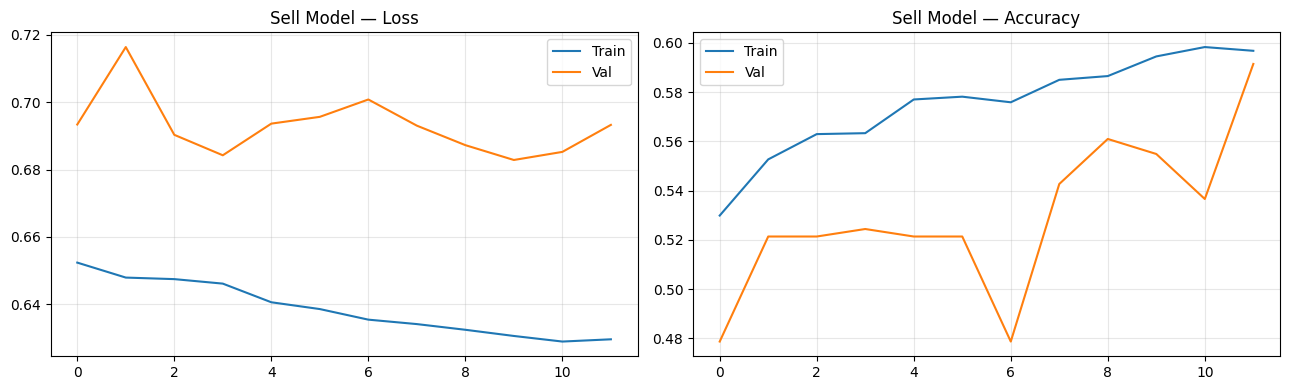

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history_sell.history['loss'],     label='Train')
ax1.plot(history_sell.history['val_loss'], label='Val')
ax1.set_title('Sell Model — Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history_sell.history['accuracy'],     label='Train')
ax2.plot(history_sell.history['val_accuracy'], label='Val')
ax2.set_title('Sell Model — Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [68]:
sell_probs = model_sell.predict(X_te_s, verbose=0).ravel()
sell_preds = (sell_probs >= 0.5).astype(int)

print('=== Task 3.2 — Sell Signal (VCB) ===')
print(classification_report(y_te_s, sell_preds,
                             target_names=['No signal', 'Sell'],
                             zero_division=0))
sell_auc = roc_auc_score(y_te_s, sell_probs)
print(f'ROC-AUC : {sell_auc:.4f}')
print(f'F1      : {f1_score(y_te_s, sell_preds, zero_division=0):.4f}')

=== Task 3.2 — Sell Signal (VCB) ===
              precision    recall  f1-score   support

   No signal       0.00      0.00      0.00       163
        Sell       0.50      1.00      0.67       165

    accuracy                           0.50       328
   macro avg       0.25      0.50      0.33       328
weighted avg       0.25      0.50      0.34       328

ROC-AUC : 0.6496
F1      : 0.6694


## Task 3 — Cross-Validation

We apply the same `TimeSeriesSplit` CV used in Task 1. The scaler is **not** re-fitted inside CV folds here because it was already fitted on the training portion of the full dataset, and all CV fold training sets are subsets of that original training set — so there is no future-data leakage from the scaling step.

In [69]:
tscv_cls = TimeSeriesSplit(n_splits=5)
print('=== 5-Fold TimeSeriesSplit CV ===')

for signal, X_all_cv, y_all_cv, cw in [
    ('BUY',  X_all_buy,  y_all_buy,  cw_buy),
    ('SELL', X_all_sell, y_all_sell, cw_sell)
]:
    fold_aucs, fold_f1s = [], []
    for fold, (tr_idx, vl_idx) in enumerate(tscv_cls.split(X_all_cv)):
        m = build_cls_model(WIN_CLS, len(ALL_FEAT_T3))
        cb = [EarlyStopping(patience=7, restore_best_weights=True, verbose=0)]
        m.fit(X_all_cv[tr_idx], y_all_cv[tr_idx],
              validation_data=(X_all_cv[vl_idx], y_all_cv[vl_idx]),
              epochs=50, batch_size=32,
              class_weight=cw, callbacks=cb, verbose=0)
        probs = m.predict(X_all_cv[vl_idx], verbose=0).ravel()
        preds = (probs >= 0.5).astype(int)
        try:
            auc = roc_auc_score(y_all_cv[vl_idx], probs)
        except ValueError:
            auc = float('nan')
        f1 = f1_score(y_all_cv[vl_idx], preds, zero_division=0)
        fold_aucs.append(auc); fold_f1s.append(f1)
        print(f'  {signal} Fold {fold+1}: AUC={auc:.4f}  F1={f1:.4f}')
    print(f'  {signal} CV AUC: {np.nanmean(fold_aucs):.4f} ± {np.nanstd(fold_aucs):.4f}')
    print(f'  {signal} CV F1 : {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}\n')

=== 5-Fold TimeSeriesSplit CV ===
  BUY Fold 1: AUC=0.6585  F1=0.4484
  BUY Fold 2: AUC=0.5248  F1=0.0000
  BUY Fold 3: AUC=0.4678  F1=0.7497
  BUY Fold 4: AUC=0.4862  F1=0.7468
  BUY Fold 5: AUC=0.5654  F1=0.6724
  BUY CV AUC: 0.5405 ± 0.0679
  BUY CV F1 : 0.5235 ± 0.2839

  SELL Fold 1: AUC=0.5613  F1=0.7205
  SELL Fold 2: AUC=0.5725  F1=0.6659
  SELL Fold 3: AUC=0.6619  F1=0.5786
  SELL Fold 4: AUC=0.5065  F1=0.0508
  SELL Fold 5: AUC=0.4881  F1=0.0000
  SELL CV AUC: 0.5581 ± 0.0609
  SELL CV F1 : 0.4032 ± 0.3121



---
# TASK 4 — Portfolio Composition, Risk Management & Optimization
---

We build two distinct portfolios from the Banks-sector tickers selected in Task 2:

1. **Task 4.1 — Profitable stock selection.** Each stock is scored by its predicted future return (from a CNN-LSTM regression model), annualised historical return, and Sharpe ratio, combined into a single profitability score.
2. **Task 4.2 — Risk management.** Each stock's risk is quantified by historical volatility and maximum drawdown, combined into a risk score. High-risk stocks are down-weighted in the conservative portfolio.
3. **Task 4.3 — Portfolio construction.** Two portfolios are assembled: an *aggressive* portfolio that maximises expected return, and a *conservative* portfolio that maximises the return-to-risk ratio. Weights are allocated using the inverse-volatility method, which is a simple and robust alternative to full mean-variance optimisation when the number of assets is small.

## Task 4.1 — Profitable Stock Selection

A lightweight CNN-LSTM regression model predicts the 10-day forward return for each ticker. The model's mean prediction on the test set provides a forward-looking profitability signal that complements purely backward-looking measures such as historical Sharpe.

In [70]:
# ── Technical indicator helpers (Task 4) ─────────────────────
def sma_t4(s, w):     return s.rolling(w).mean()
def ema_t4(s, span):  return s.ewm(span=span, adjust=False).mean()

def rsi_t4(s, period=14):
    delta = s.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    return 100 - 100 / (1 + gain / (loss + 1e-8))

def macd_t4(s, fast=12, slow=26, signal=9):
    ml  = ema_t4(s, fast) - ema_t4(s, slow)
    sig = ema_t4(ml, signal)
    return ml, sig, ml - sig

def bollinger_t4(s, w=20, n_std=2):
    mid = sma_t4(s, w)
    std = s.rolling(w).std()
    return mid + n_std * std, mid, mid - n_std * std


def add_indicators_t4(df):
    d = df.copy()
    c = d['Close']; v = d['Volume']

    d['SMA5']  = sma_t4(c, 5)
    d['SMA20'] = sma_t4(c, 20)
    d['SMA60'] = sma_t4(c, 60)
    d['EMA12'] = ema_t4(c, 12)
    d['EMA26'] = ema_t4(c, 26)
    d['RSI14'] = rsi_t4(c, 14)

    ml, sig, hist = macd_t4(c)
    d['MACD']     = ml
    d['MACDsig']  = sig
    d['MACDhist'] = hist

    bb_up, bb_mid, bb_low = bollinger_t4(c)
    d['BBwidth']   = (bb_up - bb_low) / (bb_mid + 1e-8)
    d['Return1']   = c.pct_change(1)
    d['Return5']   = c.pct_change(5)
    d['VolChange'] = v.pct_change()

    d = d.replace([np.inf, -np.inf], np.nan)
    d = d.ffill().dropna().reset_index(drop=True)
    return d

print('Indicators ready.')

Indicators ready.


In [71]:
FEATURES_T4 = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'SMA5', 'SMA20', 'SMA60',
    'EMA12', 'EMA26',
    'RSI14',
    'MACD', 'MACDsig', 'MACDhist',
    'BBwidth',
    'Return1', 'Return5',
    'VolChange'
]

N_FEAT_T4 = len(FEATURES_T4)
print(f'Total features: {N_FEAT_T4}')
print(FEATURES_T4)

Total features: 18
['Open', 'High', 'Low', 'Close', 'Volume', 'SMA5', 'SMA20', 'SMA60', 'EMA12', 'EMA26', 'RSI14', 'MACD', 'MACDsig', 'MACDhist', 'BBwidth', 'Return1', 'Return5', 'VolChange']


In [72]:
HORIZON_T4 = 10   # forward-return horizon in trading days
WINDOW_T4  = 60
VAL_R_T4   = 0.10
TEST_R_T4  = 0.10

def make_future_return(close, horizon=HORIZON_T4):
    future = pd.Series(close).shift(-horizon)
    return ((future - close) / (close + 1e-8)).values


def make_windows_t4(features, targets, win):
    X, y = [], []
    for i in range(len(targets) - win):
        X.append(features[i : i + win])
        y.append(targets[i + win])
    return np.array(X, np.float32), np.array(y, np.float32)


def chrono_split_t4(X, y, val=VAL_R_T4, test=TEST_R_T4):
    n    = len(X)
    n_te = int(n * test)
    n_vl = int(n * val)
    n_tr = n - n_vl - n_te
    return (X[:n_tr], y[:n_tr],
            X[n_tr:n_tr+n_vl], y[n_tr:n_tr+n_vl],
            X[n_tr+n_vl:],     y[n_tr+n_vl:])

print('Target / window / split helpers ready.')

Target / window / split helpers ready.


In [73]:
def build_reg_model_t4(window_size, n_features):
    model = Sequential([
        Conv1D(32, 3, activation='relu', padding='same',
               input_shape=(window_size, n_features)),
        MaxPooling1D(2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

print('Regression model ready.')

Regression model ready.


In [74]:
results_4 = {}

CALLBACKS_T4 = [
    EarlyStopping(patience=5,  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(patience=3, factor=0.5,             verbose=0)
]

for ticker, df_t in vn_data.items():
    print(f'\n── {ticker} ──')

    df_fi = add_indicators_t4(df_t)

    target     = make_future_return(df_fi['Close'].values, HORIZON_T4)
    df_fi['Target'] = target
    df_fi      = df_fi.dropna().reset_index(drop=True)

    feat_arr   = df_fi[FEATURES_T4].values
    target_arr = df_fi['Target'].values

    n     = len(feat_arr)
    n_te  = int(n * TEST_R_T4)
    n_vl  = int(n * VAL_R_T4)
    n_tr  = n - n_vl - n_te

    sc_t4 = MinMaxScaler()
    sc_t4.fit(feat_arr[:n_tr])
    feat_sc = sc_t4.transform(feat_arr)

    X_all, y_all = make_windows_t4(feat_sc, target_arr, WINDOW_T4)
    X_tr, y_tr, X_vl, y_vl, X_te, y_te = chrono_split_t4(X_all, y_all)
    print(f'Train={len(X_tr)} Val={len(X_vl)} Test={len(X_te)}')

    model = build_reg_model_t4(WINDOW_T4, N_FEAT_T4)
    model.fit(X_tr, y_tr,
              validation_data=(X_vl, y_vl),
              epochs=50, batch_size=32,
              callbacks=CALLBACKS_T4, verbose=0)

    pred = model.predict(X_te, verbose=0).ravel()

    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    corr = np.corrcoef(y_te, pred)[0, 1]

    # Profitability: mean predicted forward return on test set
    profit_score = pred.mean()

    returns      = df_fi['Close'].pct_change().dropna()
    volatility   = returns.std()
    cummax       = df_fi['Close'].cummax()
    drawdown     = (df_fi['Close'] - cummax) / (cummax + 1e-8)
    max_drawdown = abs(drawdown.min())
    risk_score   = 0.5 * volatility + 0.5 * max_drawdown
    final_score  = profit_score / (risk_score + 1e-8)

    results_4[ticker] = {
        'RMSE': rmse, 'MAE': mae, 'Corr': corr,
        'ProfitScore': profit_score,
        'Volatility':  volatility,
        'MaxDrawdown': max_drawdown,
        'RiskScore':   risk_score,
        'FinalScore':  final_score
    }

    print(f'RMSE={rmse:.5f}  Corr={corr:.4f}  '
          f'ProfitScore={profit_score:.5f}  RiskScore={risk_score:.5f}')


── ACB ──
Train=3139 Val=392 Test=392
RMSE=0.07015  Corr=0.0160  ProfitScore=-0.03776  RiskScore=0.42162

── CTG ──
Train=2618 Val=327 Test=327
RMSE=0.06994  Corr=0.2715  ProfitScore=0.00407  RiskScore=0.28266

── EIB ──
Train=2560 Val=320 Test=320
RMSE=0.12795  Corr=0.1185  ProfitScore=-0.01975  RiskScore=0.29493

── MBB ──
Train=2160 Val=269 Test=269
RMSE=0.07932  Corr=0.0223  ProfitScore=-0.01182  RiskScore=0.26617

── NVB ──
Train=2386 Val=298 Test=298
RMSE=0.12225  Corr=-0.0487  ProfitScore=0.00572  RiskScore=0.34857

── SHB ──
Train=2664 Val=333 Test=333
RMSE=0.09953  Corr=0.0375  ProfitScore=-0.05661  RiskScore=0.39772

── STB ──
Train=3216 Val=401 Test=401
RMSE=0.10752  Corr=-0.2608  ProfitScore=-0.05318  RiskScore=0.42626

── VCB ──
Train=2628 Val=328 Test=328
RMSE=0.05734  Corr=0.0563  ProfitScore=-0.00515  RiskScore=0.25651


## Task 4.2 — Risk Management

Risk for each stock is summarised by two complementary measures:
- **Volatility** (daily return standard deviation) captures typical day-to-day fluctuation.
- **Maximum drawdown** captures the worst peak-to-trough decline, reflecting tail risk.

Both are weighted equally in the composite risk score. Stocks with higher risk scores are penalised in the conservative portfolio (Task 4.3).

In [75]:
df_portfolio = pd.DataFrame([
    {
        'Ticker':      t,
        'ProfitScore': v['ProfitScore'],
        'RiskScore':   v['RiskScore'],
        'FinalScore':  v['FinalScore'],
        'Volatility':  v['Volatility'],
        'MaxDrawdown': v['MaxDrawdown'],
        'Corr':        v['Corr']
    }
    for t, v in results_4.items()
])

df_portfolio = df_portfolio.sort_values('FinalScore', ascending=False).reset_index(drop=True)
print(df_portfolio.round(5).to_string(index=False))

Ticker  ProfitScore  RiskScore  FinalScore  Volatility  MaxDrawdown     Corr
   NVB      0.00572    0.34857     0.01640     0.02964      0.66751 -0.04870
   CTG      0.00407    0.28266     0.01439     0.02157      0.54376  0.27150
   VCB     -0.00515    0.25651    -0.02009     0.01966      0.49336  0.05628
   MBB     -0.01182    0.26617    -0.04440     0.01844      0.51390  0.02226
   EIB     -0.01975    0.29493    -0.06697     0.01961      0.57024  0.11850
   ACB     -0.03776    0.42162    -0.08957     0.02131      0.82192  0.01601
   STB     -0.05318    0.42626    -0.12476     0.02339      0.82913 -0.26075
   SHB     -0.05661    0.39772    -0.14233     0.02584      0.76960  0.03745


## Task 4.3 — Portfolio Construction

We build two portfolios from the top-5 candidates under each strategy:

- **Aggressive portfolio:** top 5 by `ProfitScore` (maximise expected return).
- **Conservative portfolio:** top 5 by `FinalScore` (maximise return per unit of risk).

Weights are allocated using the **inverse-volatility** method: each stock receives a weight proportional to 1/σ, then normalised to sum to 1. This approach tilts the portfolio away from high-volatility assets without requiring a full covariance matrix estimate, which tends to be noisy with a small number of assets.

In [82]:
# ── Aggressive Portfolio ──────────────────────────────────────

aggressive = (
    df_portfolio[df_portfolio['ProfitScore'] > 0]
    .sort_values('ProfitScore', ascending=False)
    .head(5)
    .copy()
)

# Weight proportional to ProfitScore
weights = aggressive['ProfitScore'].clip(lower=0)
aggressive['Weight'] = weights / weights.sum()

print('=== Aggressive Portfolio ===')

print(
    aggressive[
        ['Ticker', 'ProfitScore', 'RiskScore', 'Weight']
    ].round(5).to_string(index=False)
)

print(
    f'\nExpected portfolio return (weighted): '
    f"{(aggressive['ProfitScore'] * aggressive['Weight']).sum():.5f}"
)

=== Aggressive Portfolio ===
Ticker  ProfitScore  RiskScore  Weight
   NVB      0.00572    0.34857 0.58417
   CTG      0.00407    0.28266 0.41583

Expected portfolio return (weighted): 0.00503


In [83]:
# ── Conservative Portfolio ────────────────────────────────────

conservative = (
    df_portfolio[df_portfolio['ProfitScore'] > 0]
    .sort_values(
        ['RiskScore', 'ProfitScore'],
        ascending=[True, False]
    )
    .head(5)
    .copy()
)

# Inverse-volatility weighting
inv_vol = 1.0 / (conservative['Volatility'] + 1e-8)
conservative['Weight'] = inv_vol / inv_vol.sum()

print('\n=== Conservative Portfolio ===')

print(
    conservative[
        ['Ticker', 'ProfitScore', 'RiskScore', 'Weight']
    ].round(5).to_string(index=False)
)

print(
    f'\nExpected portfolio return (weighted): '
    f"{(conservative['ProfitScore'] * conservative['Weight']).sum():.5f}"
)


=== Conservative Portfolio ===
Ticker  ProfitScore  RiskScore  Weight
   CTG      0.00407    0.28266  0.5788
   NVB      0.00572    0.34857  0.4212

Expected portfolio return (weighted): 0.00476
